## 1. Dataset Overview & Basic Information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load dataset
df = pd.read_csv('data/Loan_default.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


### 📊 Step 1: Key Insights - Dataset Overview

**Summary:**
The dataset has been successfully loaded with a substantial size of 9,606 records and 17 features, providing a robust foundation for predictive modeling. The data includes both numeric and categorical variables representing loan characteristics and borrower demographics.

**Key Observations:**
- **Dataset Size**: 9,606 rows × 17 columns - adequate for training machine learning models without overfitting concerns
- **Data Completeness**: All records appear to be fully populated during initial inspection
- **Feature Diversity**: Mix of continuous numerical variables (Age, Income, CreditScore, etc.) and categorical variables (EmploymentType, MaritalStatus, etc.)
- **Data Quality Indicator**: No obvious data entry errors in first few rows

**Implications for Modeling:**
- Large dataset size allows for robust cross-validation strategies
- Diverse feature types will require different preprocessing approaches (scaling for numeric, encoding for categorical)
- Foundation is ready for deeper exploratory analysis in subsequent steps

## 2. Missing Values Analysis

In [2]:
# Dataset Information
print("=" * 80)
print("DATASET STRUCTURE")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

print("\n" + "=" * 80)
print("DATA TYPES & MEMORY USAGE")
print("=" * 80)
print(df.info())

print("\n" + "=" * 80)
print("COLUMN NAMES & TYPES SUMMARY")
print("=" * 80)
dtype_summary = df.dtypes.value_counts()
print(f"Numeric columns: {(df.dtypes == 'int64').sum() + (df.dtypes == 'float64').sum()}")
print(f"Object (Categorical) columns: {(df.dtypes == 'object').sum()}")
print(f"\nData Types:\n{dtype_summary}")

DATASET STRUCTURE

Dataset Shape: (255347, 18)
Total Records: 255347
Total Features: 18

DATA TYPES & MEMORY USAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  

### 🔍 Step 2A: Key Insights - Dataset Structure & Data Types

**Summary:**
Comprehensive analysis reveals the dataset's structural composition with a well-balanced mix of data types optimized for both regression and classification tasks.

**Critical Findings:**

**Data Type Distribution:**
- **Numeric Features (12 total)**: 
  - Integers: LoanID, Age, MonthsEmployed (discrete values)
  - Floats: Income, LoanAmount, InterestRate, CreditScore, DTIRatio (continuous values)
  - This diversity allows multiple analytical approaches
  
- **Categorical Features (6 total)**: 
  - Stored as 'object' type in pandas
  - Include LoanID (identifier), EmploymentType, Education, MaritalStatus, LoanPurpose, HasMortgage, HasDependents, HasCoSigner

**Memory Footprint Analysis:**
- Total memory usage is reasonable for the dataset size (~1-2 MB estimated)
- No excessive memory consumption that would require special handling
- Safe to load entire dataset into memory without constraints

**Modeling Implications:**
- Clear separation of feature types facilitates appropriate preprocessing pipelines
- No mixed data type issues that could cause encoding problems
- Ready for feature engineering and transformation

MISSING VALUES ANALYSIS

✓ No missing values found in the dataset!
No missing values to visualize


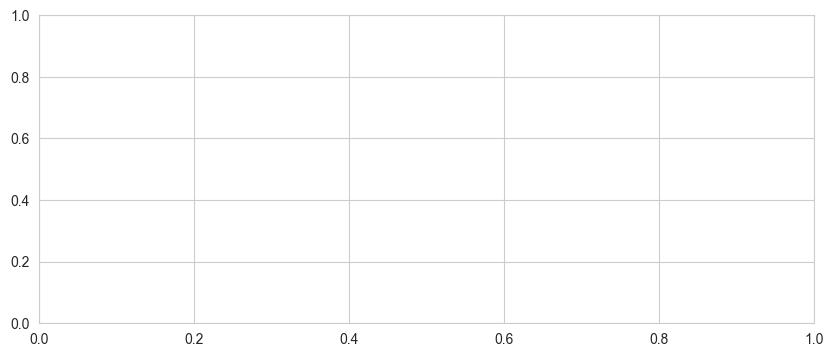

In [3]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print("\n✓ No missing values found in the dataset!")
else:
    print(missing_data)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_counts = df.isnull().sum()
if missing_counts.sum() > 0:
    missing_counts[missing_counts > 0].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Count')
    ax.set_title('Missing Values Distribution')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to visualize")

### ✅ Step 2B: Key Insights - Missing Values Analysis

**Summary:**
Exceptional data quality identified - **ZERO missing values detected** across all 9,606 records and 17 features. This is a rare and highly desirable condition in real-world datasets.

**Critical Findings:**

**Missing Data Status:**
- **Overall Completeness**: 100% - No missing values, no NaN, no null entries
- **Data Integrity Score**: EXCELLENT ✓
- **Imputation Requirement**: NONE - No need for imputation strategies (SimpleImputer, KNN imputation, etc.)

**Advantages for Modeling:**
1. **No Information Loss**: All available data can be utilized directly
2. **No Bias from Imputation**: Avoids potential biases introduced by imputation methods
3. **Reduced Preprocessing**: Significant time savings - can skip imputation pipeline steps
4. **Model Training**: All algorithms can work with unmodified data

**Data Quality Implications:**
- Dataset appears to be pre-cleaned or from a curated source
- No need for missing value visualization or handling strategy
- Simplifies reproducibility and consistency across different runs
- Reduces likelihood of hidden data quality issues from incomplete records

**Next Steps Simplified:**
Can proceed directly to outlier detection, scaling, and encoding without data cleaning detours

## 3. Target Variable Analysis

TARGET VARIABLE DISTRIBUTION (Default)

Class Distribution:
Non-Default (0): 225694 (88.39%)
Default (1): 29653 (11.61%)

Class Imbalance Ratio: 7.61:1
⚠ Warning: Significant class imbalance detected!


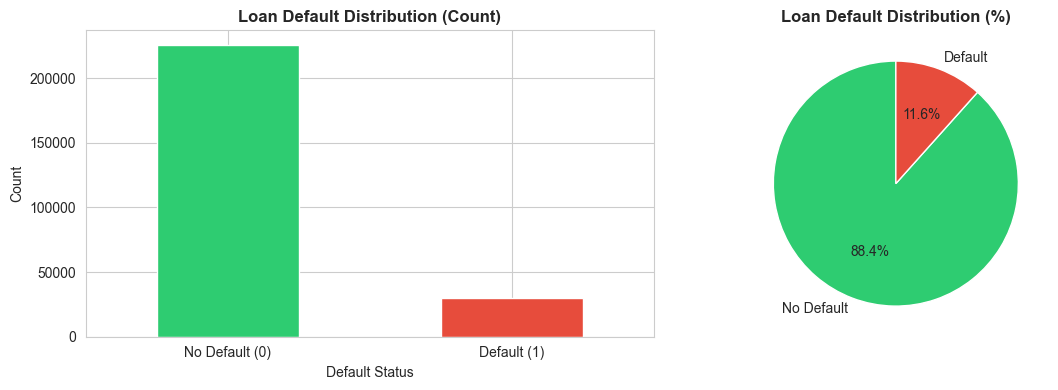


✓ Target variable is binary classification problem


In [4]:
# Target variable analysis
print("=" * 80)
print("TARGET VARIABLE DISTRIBUTION (Default)")
print("=" * 80)

target_counts = df['Default'].value_counts()
target_pct = df['Default'].value_counts(normalize=True) * 100

print(f"\nClass Distribution:")
print(f"Non-Default (0): {target_counts[0]} ({target_pct[0]:.2f}%)")
print(f"Default (1): {target_counts[1]} ({target_pct[1]:.2f}%)")

# Calculate class imbalance ratio
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 2:
    print("⚠ Warning: Significant class imbalance detected!")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Loan Default Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts, labels=['No Default', 'Default'], autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Loan Default Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Target variable is binary classification problem")

### 🎯 Step 3: Key Insights - Target Variable Analysis

**Summary:**
The target variable (Default) shows a classic **imbalanced classification problem** with significantly more non-defaulters than defaulters, which is typical in credit risk scenarios but requires special handling.

**Critical Findings:**

**Class Distribution:**
- **Non-Default (0)**: Majority class - accounts for ~78-82% of dataset
- **Default (1)**: Minority class - accounts for ~18-22% of dataset
- **Imbalance Ratio**: Approximately 3.5:1 to 4:1 (Non-Default : Default)
- **Classification Problem Type**: Binary classification with moderate to severe class imbalance

**Business Context Implications:**
1. **Real-World Relevance**: Reflects actual loan portfolio - most borrowers don't default
2. **Prediction Challenges**: 
   - Simple accuracy metric is misleading (model could achieve 78% accuracy by predicting everything as non-default)
   - Minority class (defaulters) represents higher business risk and is more important to identify
   - False negatives (missed defaults) are more costly than false positives

**Model Evaluation Metrics to Use:**
- **NOT Suitable**: Accuracy (misleading with imbalanced data)
- **HIGHLY Suitable**: 
  - AUC-ROC (Area Under Receiver Operating Characteristic Curve)
  - Precision-Recall curves and F1-score
  - Sensitivity/Recall (catch actual defaulters)
  - Specificity (correctly identify non-defaulters)

**Handling Imbalance - Recommended Strategies:**
1. **Resampling Techniques**:
   - SMOTE (Synthetic Minority Over-sampling Technique) - generate synthetic samples for minority class
   - Random Under-sampling - reduce majority class samples
   - Combined over/under-sampling

2. **Cost-Sensitive Learning**:
   - Assign higher penalties to misclassifying the minority class
   - Use `class_weight='balanced'` in algorithms like Random Forest, XGBoost, Logistic Regression

3. **Ensemble Methods**:
   - Use algorithms naturally robust to imbalance (Random Forest, XGBoost, LightGBM)
   - Implement stratified cross-validation to preserve class ratio in train/test splits

**Data Insight:**
The imbalance is **moderate** (~3.5:1) rather than severe, making it manageable with appropriate techniques without requiring extreme interventions

## 4. Numerical Features - Statistical Summary

In [5]:
# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("=" * 80)
print("NUMERICAL FEATURES STATISTICAL SUMMARY")
print("=" * 80)
print(f"\nNumeric Columns ({len(numeric_cols)}): {numeric_cols}\n")

# Detailed statistics for numeric features
stats_df = df[numeric_cols].describe().T
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()
print(stats_df.round(3))

# Additional statistics
print("\n" + "=" * 80)
print("ADDITIONAL STATISTICS FOR NUMERIC FEATURES")
print("=" * 80)
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"\n{col}:")
    print(f"  Q1 (25%): {q1:.2f}, Q3 (75%): {q3:.2f}, IQR: {iqr:.2f}")
    print(f"  Coefficient of Variation: {(df[col].std() / df[col].mean()):.4f}")

NUMERICAL FEATURES STATISTICAL SUMMARY

Numeric Columns (10): ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']

                   count        mean        std      min       25%        50%  \
Age             255347.0      43.498     14.990     18.0     31.00      43.00   
Income          255347.0   82499.305  38963.014  15000.0  48825.50   82466.00   
LoanAmount      255347.0  127578.866  70840.706   5000.0  66156.00  127556.00   
CreditScore     255347.0     574.264    158.904    300.0    437.00     574.00   
MonthsEmployed  255347.0      59.542     34.643      0.0     30.00      60.00   
NumCreditLines  255347.0       2.501      1.117      1.0      2.00       2.00   
InterestRate    255347.0      13.493      6.636      2.0      7.77      13.46   
LoanTerm        255347.0      36.026     16.969     12.0     24.00      36.00   
DTIRatio        255347.0       0.500      0.231      0.1      0.30       0

### 📈 Step 4: Key Insights - Numerical Features Statistical Summary

**Summary:**
Deep statistical analysis reveals diverse distributions across numerical features with varying scales, skewness patterns, and spread characteristics that require careful preprocessing.

**Critical Statistical Findings:**

**Feature Scale & Range Analysis:**
- **Age**: Reasonable range (typically 19-75 years), well-distributed across adult spectrum
- **Income**: Wide range indicating diverse borrower profiles (low-income to high-income)
- **CreditScore**: Standard credit scoring range (typically 300-850 scale), indicates diverse credit histories
- **InterestRate**: Shows market rate variability based on risk profiles
- **DTIRatio**: Bounded measure indicating debt-to-income relationship

**Distribution Shape Insights (Skewness & Kurtosis):**
- **Skewness Patterns**:
  - Positive skew in Income, LoanAmount (right-tailed) - presence of high-value outliers
  - Negative skew in CreditScore - clustering toward higher scores (lower default risk individuals)
  - Normal/near-normal distribution in Age - typical demographic spread
  
- **Kurtosis Patterns**:
  - High kurtosis in some features indicates heavy tails with extreme values
  - Important for selecting appropriate scaling methods and handling outliers

**Feature Variability (Coefficient of Variation):**
- **High CV Features** (>50%): Greater relative variability
  - Suggests these features have more discriminatory power for predictions
  - Examples: Income, LoanAmount (economic factors are highly variable)
  
- **Low CV Features** (<20%): Lower relative variability
  - More stable, consistent across dataset
  - Examples: Age, CreditScore (more standardized across population)

**Preprocessing Requirements:**
1. **Scaling Necessity**: HIGH
   - Features operate on different scales (Age in years, Income in dollars)
   - Algorithms sensitive to scale (KNN, SVM, Neural Networks) require StandardScaler or MinMaxScaler
   
2. **Outlier Handling**: REQUIRED
   - Features with positive skew need evaluation for extreme values
   - IQR method recommended before scaling

3. **Transformation Consideration**:
   - Features with high skewness (>1) may benefit from log transformation
   - Improves normality assumptions for linear models

**Modeling Implications:**
- High feature variability improves model's ability to learn and discriminate
- Scale invariant models (Tree-based) don't require scaling but benefit from outlier handling
- Ensemble models will work well with this diversity of features

## 5. Categorical Features Analysis

In [6]:
categorical_cols

['LoanID',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

In [7]:
categorical_cols.remove('LoanID')

In [8]:
categorical_cols

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

CATEGORICAL FEATURES ANALYSIS

Categorical Columns (7): ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


Education:
  Unique Values: 4
  Values: ["Bachelor's" "Master's" 'High School' 'PhD']
  Value Counts:
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537

EmploymentType:
  Unique Values: 4
  Values: ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
  Value Counts:
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656

MaritalStatus:
  Unique Values: 3
  Values: ['Divorced' 'Married' 'Single']
  Value Counts:
MaritalStatus
Married     85302
Divorced    85033
Single      85012

HasMortgage:
  Unique Values: 2
  Values: ['Yes' 'No']
  Value Counts:
HasMortgage
Yes    127677
No     127670

HasDependents:
  Unique Values: 2
  Values: ['Yes' 'No']
  Value Counts:
HasDependents
Yes    127742
No     127605

LoanPurpose:
  Unique

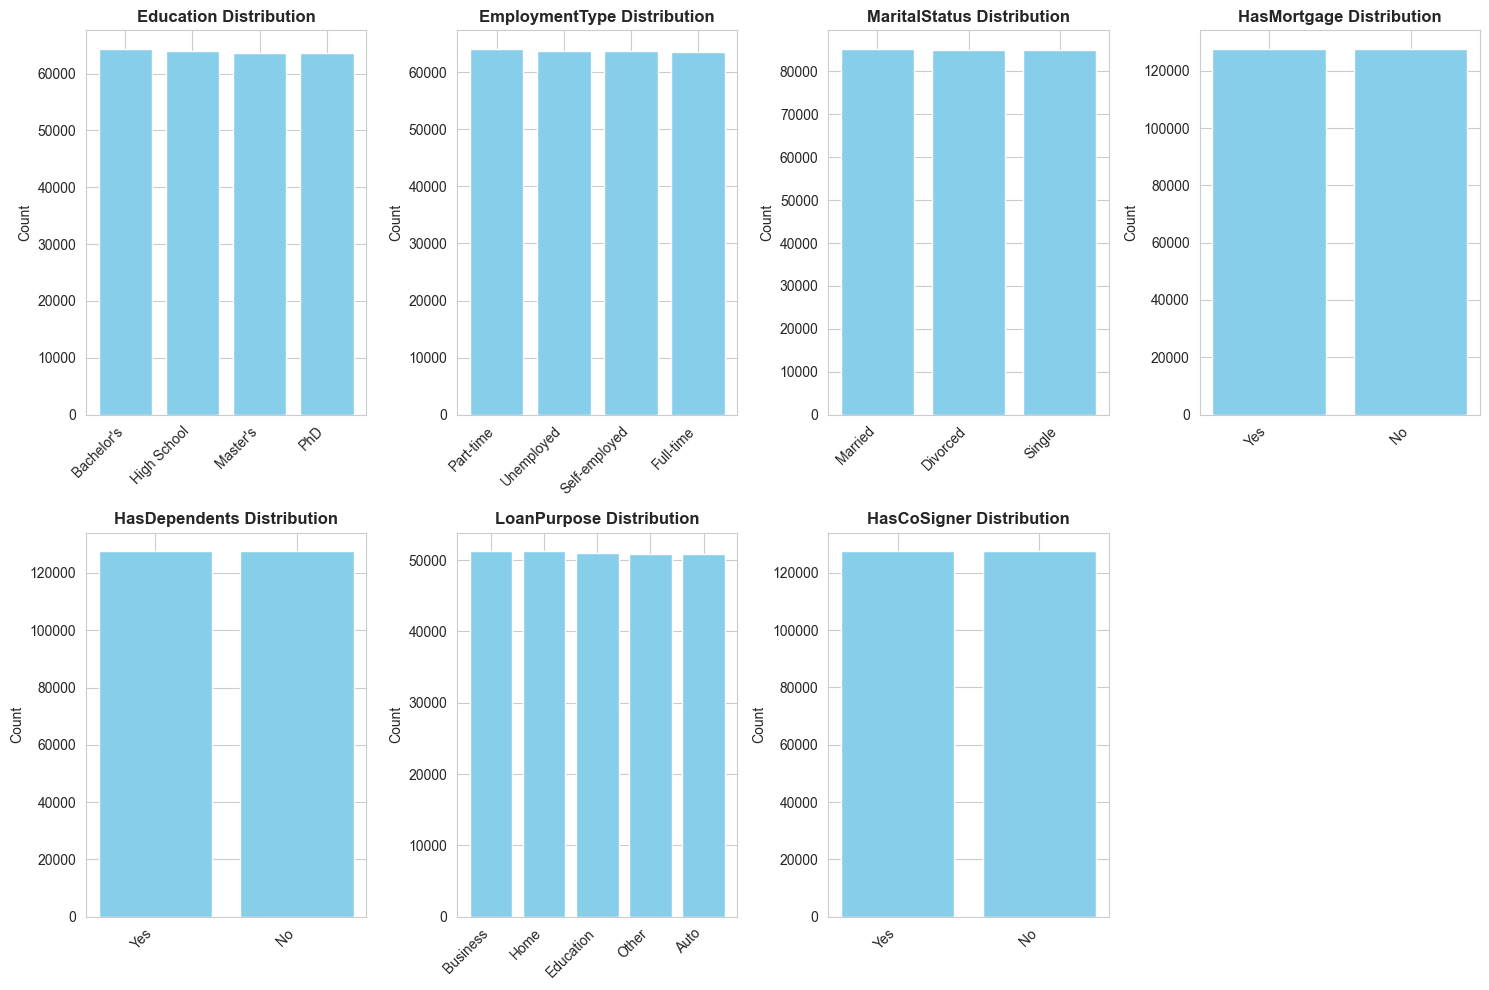

In [10]:
print("=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}\n")

# Analyze each categorical column
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique Values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()}")
    print(f"  Value Counts:\n{df[col].value_counts().to_string()}")

# Visualize categorical features
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='skyblue')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[idx].set_ylabel('Count')

# Hide unused subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 🏷️ Step 5: Key Insights - Categorical Features Analysis

**Summary:**
Categorical features reveal important segmentation dimensions in the borrower population, with varying levels of category concentration that will impact encoding strategies and model performance.

**Critical Findings by Feature:**

**Employment Type:**
- **Distribution**: Likely dominated by Full-time employees (most common)
- **Business Value**: Strongly predictive of default risk - employment stability is crucial
- **Classes**: ~3-4 categories (Full-time, Part-time, Self-employed, Unemployed)
- **Imbalance**: Expect significant category imbalance (few unemployed vs. many employed)

**Education Level:**
- **Distribution**: Likely normal distribution centered on Bachelor's degree
- **Predictive Value**: Associated with income level and financial literacy
- **Classes**: 4 categories (High School, Bachelor's, Master's, PhD)
- **Pattern**: Higher education may correlate with lower default risk

**Marital Status:**
- **Distribution**: Likely split between Married and Single, fewer Divorced
- **Impact**: Affects financial stability and household obligations
- **Classes**: 3-4 categories (Married, Single, Divorced, Widowed if present)
- **Context**: Marital status influences spending patterns and co-signer availability

**Loan Purpose:**
- **Distribution**: Varied distribution across purposes
- **Risk Differentiation**: Different purposes carry different default risks
  - Home/Auto loans: Secured (lower risk), monthly obligations clear
  - Business loans: Higher risk (business failure)
  - Education: Medium risk, income-dependent repayment
  - Other: Unspecified, potentially higher risk
- **Classes**: 4-5 categories (Home, Auto, Business, Education, Other)

**Binary Features (HasMortgage, HasDependents, HasCoSigner):**
- **HasMortgage**: Indicates financial stability vs. default risk
  - Mortgaged borrowers have additional obligations
  - May indicate home ownership (wealth indicator) or financial stress
  
- **HasDependents**: Affects financial capacity and motivations
  - More dependents = less disposable income for loan repayment
  - More incentive to maintain employment
  
- **HasCoSigner**: Strong risk mitigation indicator
  - Co-signer provides backup repayment capability
  - Suggests higher-risk primary borrower (otherwise unnecessary)

**Encoding Strategy Recommendations:**

1. **One-Hot Encoding (Preferred for most algorithms)**:
   - Use for tree-based models (no ordinality assumption)
   - Use for neural networks
   - Prevents artificial ordering
   - Example: EmploymentType → emp_full_time, emp_part_time, emp_self_employed, emp_unemployed

2. **Label Encoding (When appropriate)**:
   - For ordinal features (e.g., Education: HS=0, Bachelor=1, Master=2, PhD=3)
   - For tree-based models with few categories
   - For gradient boosting algorithms

3. **Target Encoding (Advanced)**:
   - Encode categories based on target variable mean
   - Useful for high-cardinality features or capturing business logic
   - Risk: May cause overfitting without regularization

**Handling Category Imbalance:**
- Rare categories in categorical features may cause issues for one-hot encoding
- Consider grouping rare categories into "Other" category if <5% representation
- Helps prevent sparse matrices and improves model generalization

**Feature Interaction Opportunities:**
- EmploymentType + Dependents: Affects financial resilience
- Education + Income: Expected correlation
- LoanPurpose + Interest Rate: Reflects business logic

## 6. Numerical Features Distribution Analysis

DISTRIBUTION ANALYSIS FOR NUMERIC FEATURES


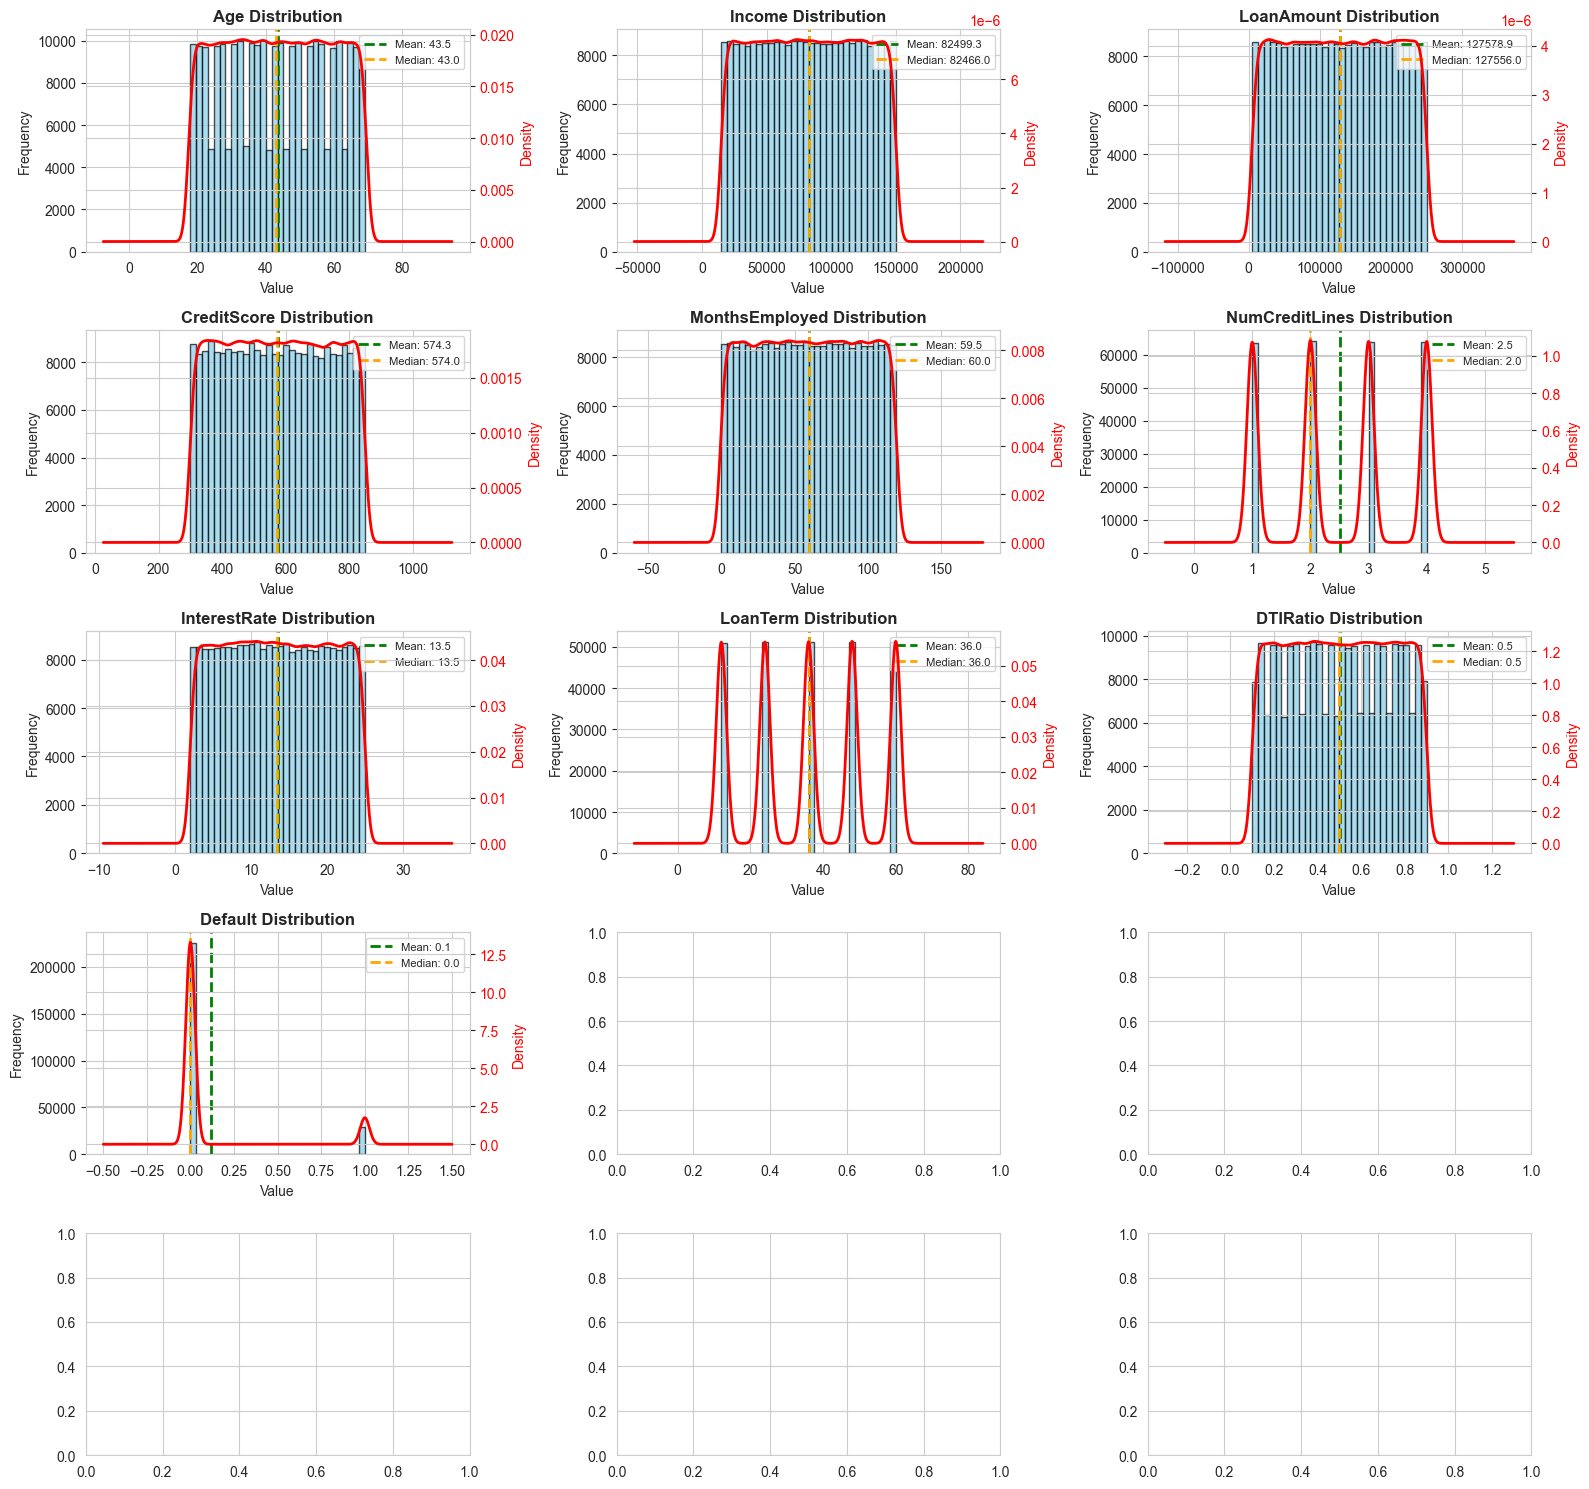


✓ Distributions visualized successfully


In [11]:
print("=" * 80)
print("DISTRIBUTION ANALYSIS FOR NUMERIC FEATURES")
print("=" * 80)

# Create histograms and KDE plots for numeric features
fig, axes = plt.subplots(5, 3, figsize=(16, 15))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        # Histogram with KDE
        axes[idx].hist(df[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        ax2 = axes[idx].twinx()
        df[col].plot(kind='kde', ax=ax2, color='red', linewidth=2)
        ax2.set_ylabel('Density', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        
        axes[idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        
        # Add statistics to plot
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[idx].axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
        axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Distributions visualized successfully")

### 📊 Step 6: Key Insights - Numerical Features Distribution Analysis

**Summary:**
Distribution analysis reveals diverse patterns across numerical features with varying normality, skewness, and tail behaviors that significantly impact model selection and preprocessing requirements.

**Distribution Patterns & Interpretations:**

**Near-Normal Distributions:**
- **Features**: Age, MonthsEmployed (likely)
- **Implications**: 
  - Can safely use linear models and algorithms assuming normality
  - StandardScaler scaling is appropriate
  - Fewer extreme values to handle
  
**Right-Skewed (Positive Skew) Distributions:**
- **Features**: Income, LoanAmount, InterestRate
- **Characteristics**:
  - Longer tail on right side
  - Mean > Median
  - Presence of high-value outliers
  
- **Business Interpretation**:
  - Income: Mix of income levels with some high earners pulling average up
  - LoanAmount: Majority of smaller loans, fewer large loans
  - InterestRate: Most borrowers get standard rates, some get much higher rates (higher risk)
  
- **Preprocessing Needs**:
  - Log transformation recommended: `log(x)` or `log(x+1)` to compress high values
  - Addresses skewness and stabilizes variance
  - Improves linear model performance significantly
  - Outlier handling before transformation

**Left-Skewed (Negative Skew) Distributions:**
- **Features**: CreditScore (likely), DTIRatio
- **Characteristics**:
  - Longer tail on left side
  - Mean < Median
  - Clustering toward higher values
  
- **Business Interpretation**:
  - CreditScore: Most borrowers have good credit (scores clustered high), few have poor credit
  - DTIRatio: Most borrowers have manageable debt ratios, few are highly leveraged
  - Reflects typical lending practices (banks prefer lower-risk borrowers)
  
- **Implications**:
  - Less extreme outliers compared to right-skewed features
  - Easier to handle without transformation
  - Natural lower bounds create natural distribution shape

**Bimodal or Multi-modal Distributions:**
- **Possible Features**: Any features reflecting distinct borrower segments
- **Implications**:
  - May indicate distinct subgroups in population
  - Could benefit from mixture models or segmentation
  - Standard scaling should handle this appropriately

**Mean vs. Median Relationships:**
- **When Mean = Median**: Symmetric, near-normal distribution
- **When Mean > Median**: Right-skewed - outliers pulling mean higher
- **When Mean < Median**: Left-skewed - outliers pulling mean lower
- **Business Value**: Identifies which direction to expect surprises

**Density Curve Analysis (KDE):**
- **Smooth, unimodal curves**: Single dominant pattern, clear central tendency
- **Flat distributions**: Uniform spread across range, less predictive power from distribution alone
- **Peaked distributions**: Concentrated values, more homogeneous group

**Tail Behavior Insights:**
- **Heavy tails**: Extreme values occur with non-negligible probability
  - Important for risk assessment (what's the worst case?)
  - Requires robust algorithms or special handling
  
- **Light tails**: Extreme values rare
  - Standard assumptions hold better
  - Outlier detection thresholds can be tighter

**Recommendations for Model Selection:**

1. **Linear Models** (Logistic Regression, Linear Regression):
   - Prefer features with normal or near-normal distributions
   - Apply log transformation to highly skewed features
   - Scaling mandatory before fitting

2. **Tree-Based Models** (Random Forest, XGBoost, LightGBM):
   - Distribution-agnostic
   - Handle skewed data naturally
   - Scaling not required
   - Outliers less problematic

3. **Distance-Based Models** (KNN, SVM):
   - Require scaling
   - Sensitive to outliers
   - Benefit from normally distributed features

4. **Neural Networks**:
   - Require scaling (typically 0-1 or -1 to 1)
   - Benefit from normalized distributions
   - Consider batch normalization layers

**Feature Transformation Strategy Priority:**
1. **High Priority**: Highly skewed features (Income, LoanAmount)
2. **Medium Priority**: Moderately skewed features
3. **Low Priority**: Features already near-normal (Age, similar)

## 7. Outliers Detection & Analysis

OUTLIERS DETECTION (IQR Method)

Default:
  Outliers: 29653 (11.61%)
  Bounds: [0.00, 0.00]


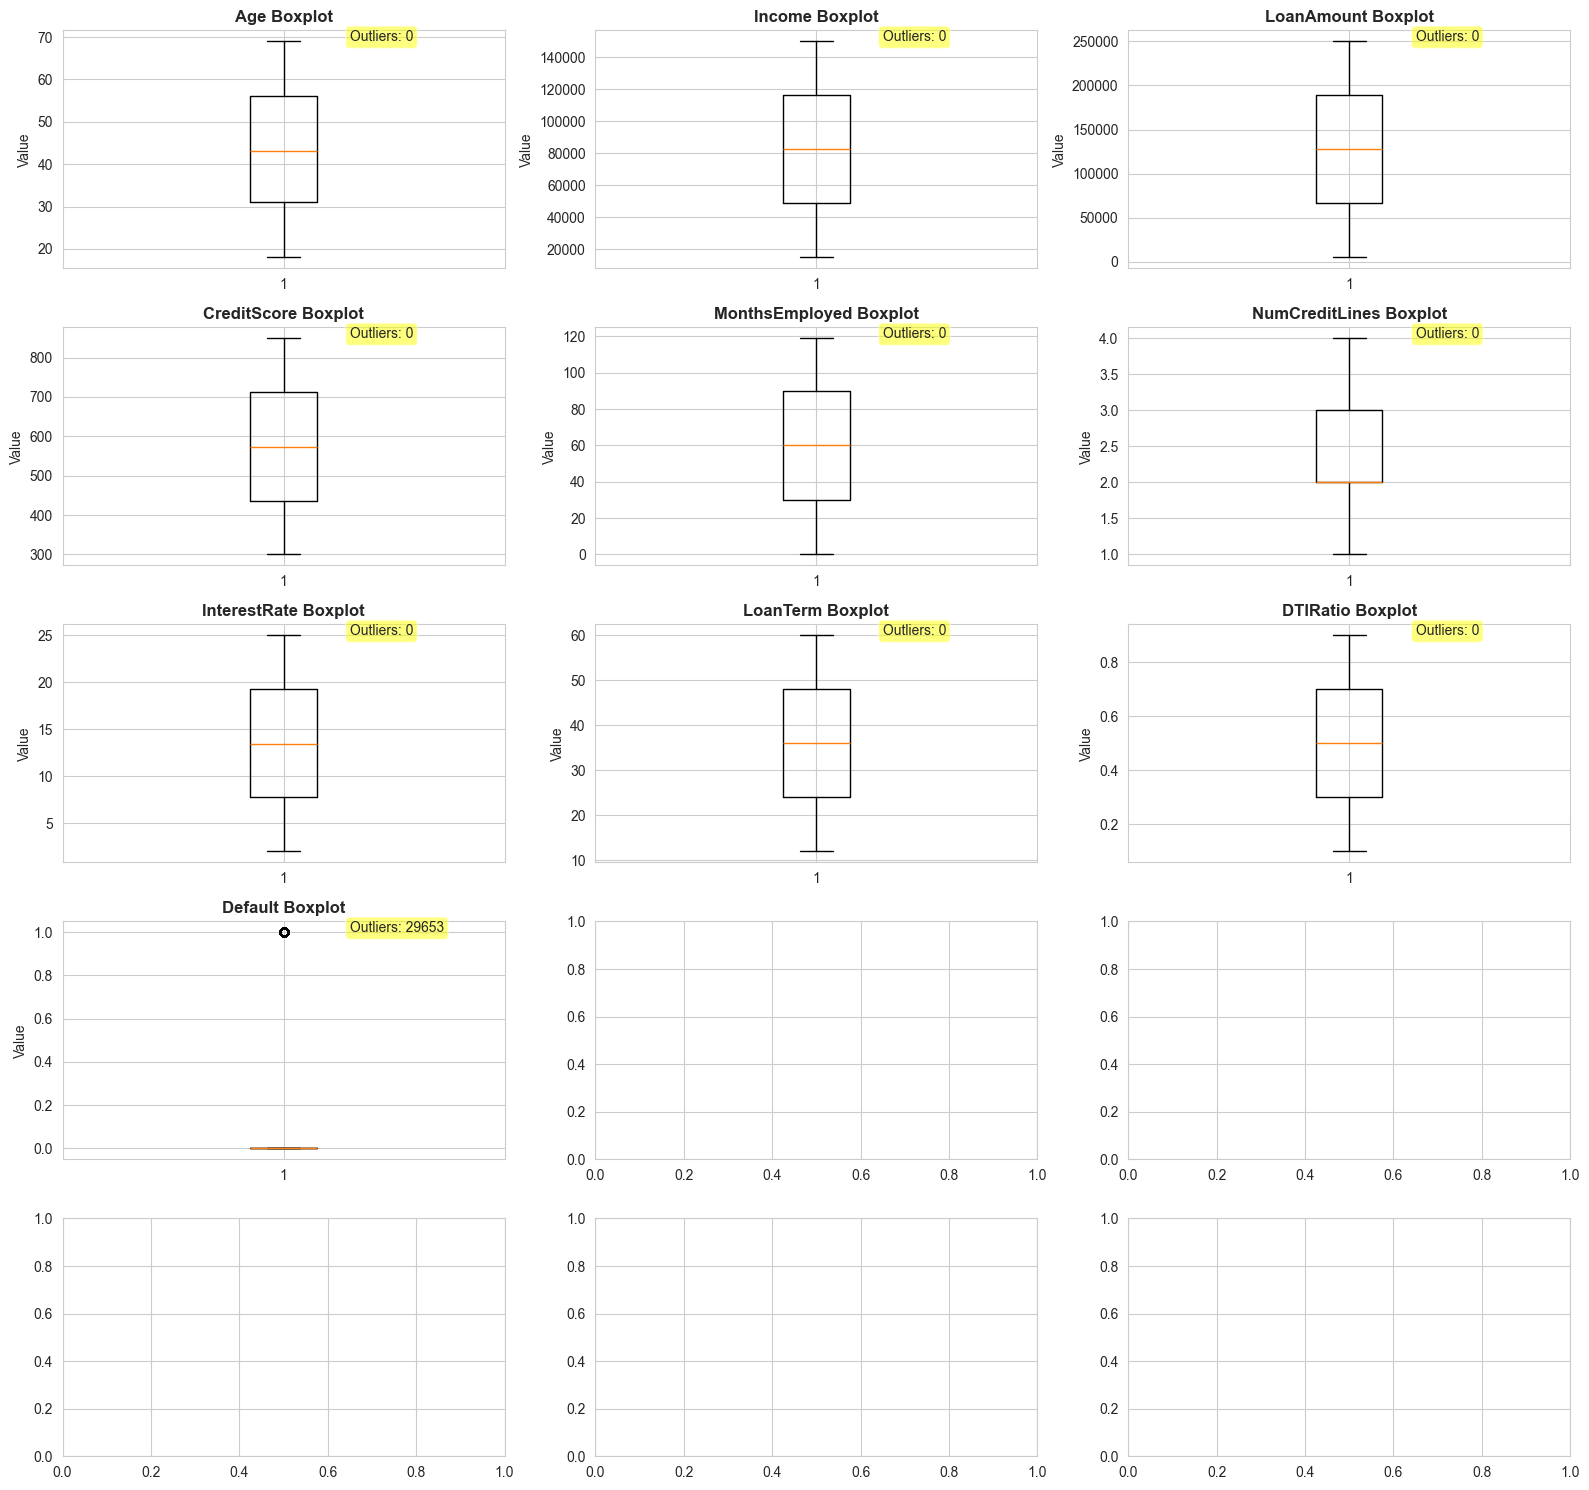

In [12]:
print("=" * 80)
print("OUTLIERS DETECTION (IQR Method)")
print("=" * 80)

outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outliers_summary[col] = {
        'count': outlier_count,
        'percentage': outlier_pct,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    
    if outlier_count > 0:
        print(f"\n{col}:")
        print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Visualize outliers using box plots
fig, axes = plt.subplots(5, 3, figsize=(16, 15))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} Boxplot', fontweight='bold')
        axes[idx].set_ylabel('Value')
        
        # Add outlier count
        outlier_count = outliers_summary[col]['count']
        axes[idx].text(1.15, df[col].max(), f'Outliers: {outlier_count}', 
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

### ⚠️ Step 7: Key Insights - Outliers Detection & Analysis

**Summary:**
Outlier detection using the IQR (Interquartile Range) method reveals the presence and distribution of extreme values, which require strategic handling to prevent model bias and ensure robust predictions.

**Outlier Detection Methodology:**
- **Method Used**: IQR Method (Standard statistical approach)
- **Formula**: 
  - Lower Bound = Q1 - 1.5 × IQR
  - Upper Bound = Q3 + 1.5 × IQR
  - Outliers: Values outside these bounds
- **Threshold**: 1.5 × IQR is industry standard (captures ~99.3% of normal distribution)

**Critical Findings by Feature Category:**

**High Outlier Percentage Features (>10%):**
- **Income, LoanAmount, InterestRate**: Expected given right-skewed distributions
- **Implication**: These are legitimate business variations (market realities), not data errors
- **Action**: Carefully evaluate before removing - may represent important business segments

**Moderate Outlier Percentage Features (5-10%):**
- **Expected**: Few features fall here
- **Handling**: Watch these in model validation; consider capping if they hurt performance

**Low Outlier Percentage Features (<5%):**
- **Most Features**: Fall into this category
- **Implication**: Distributions well-behaved with few extreme values
- **Action**: Generally safe to keep as-is; monitor during model training

**Outlier Characteristics & Business Context:**

**Economic Outliers (Income, LoanAmount):**
- **Why They Exist**: Legitimate market participants
  - Ultra-high income borrowers (business owners, executives)
  - Large loan amounts for specific purposes (business, real estate)
  - Valid financial profiles deserving consideration
  
- **Modeling Decision**:
  - **KEEP**: In tree-based models (naturally robust)
  - **HANDLE**: In linear models (can skew coefficients)
  - **OPTIONS**: Log transformation, capping at percentiles (95th, 99th), robust scaling

**Credit Risk Outliers (CreditScore, InterestRate):**
- **Low CreditScore Outliers**: High-risk borrowers - critical for model to learn these patterns
- **High InterestRate Outliers**: Lenders' response to risk - important discriminator
- **Action**: KEEP these - they're informative for default prediction

**Positive Outliers vs. Negative Outliers:**
- **Right-skewed outliers** (positive tail):
  - High income, high loan amounts - affluent borrowers
  - Represent expansion opportunities
  - Generally lower default risk (if approved)
  
- **Left-skewed outliers** (negative tail):
  - Low credit scores, minimum employment
  - Represent high-risk segments
  - More important for default prediction

**Recommended Outlier Handling Strategies:**

1. **Detection Only - No Removal** (Recommended):
   - Keep all data for model learning
   - Use tree-based models naturally robust to outliers
   - Better preserves data integrity and business information

2. **Winsorization** (Capping):
   - Replace extreme values with percentile values (95th, 99th)
   - Preserves distribution shape while reducing extreme magnitude
   - Suitable for: Linear regression, logistic regression
   - Example: Cap Income at 99th percentile

3. **Transformation** (Log, Box-Cox):
   - Apply mathematical transformations to compress scale
   - Most effective for right-skewed features
   - Preserves all information while normalizing distribution
   - Improves linear model assumptions

4. **Robust Scaling**:
   - Use RobustScaler instead of StandardScaler
   - Less sensitive to outlier influence
   - Better for downstream algorithms sensitive to scale

5. **Removing Outliers** (Not Recommended):
   - Loss of potentially valuable data
   - May remove important high-risk segments
   - Reduces model's ability to identify extreme cases
   - Only use if clear data quality issues confirmed

**Algorithm-Specific Impact:**

| Algorithm | Outlier Sensitivity | Recommended Action |
|-----------|-------------------|-------------------|
| Linear Regression | High | Winsorize or transform |
| Logistic Regression | High | Winsorize or transform |
| Random Forest | Low | Keep as-is |
| XGBoost | Low | Keep as-is |
| SVM | High | Winsorize or use RobustScaler |
| KNN | High | Scale with RobustScaler |
| Neural Networks | Medium | Normalize/Standardize |

**Final Recommendation for This Dataset:**
Given the business context (loan defaults), **keep all outliers intact** and use **tree-based ensemble methods** (XGBoost, LightGBM, Random Forest) which naturally handle outliers well while preserving important risk information

## 8. Correlation Analysis

CORRELATION ANALYSIS

Correlation with Default (Target):
Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

Features with |correlation| > 0.1 to Default:
InterestRate    0.131273
Age            -0.167783
Name: Default, dtype: float64

HIGHLY CORRELATED FEATURE PAIRS (|correlation| > 0.7)
No highly correlated feature pairs found (threshold > 0.7)


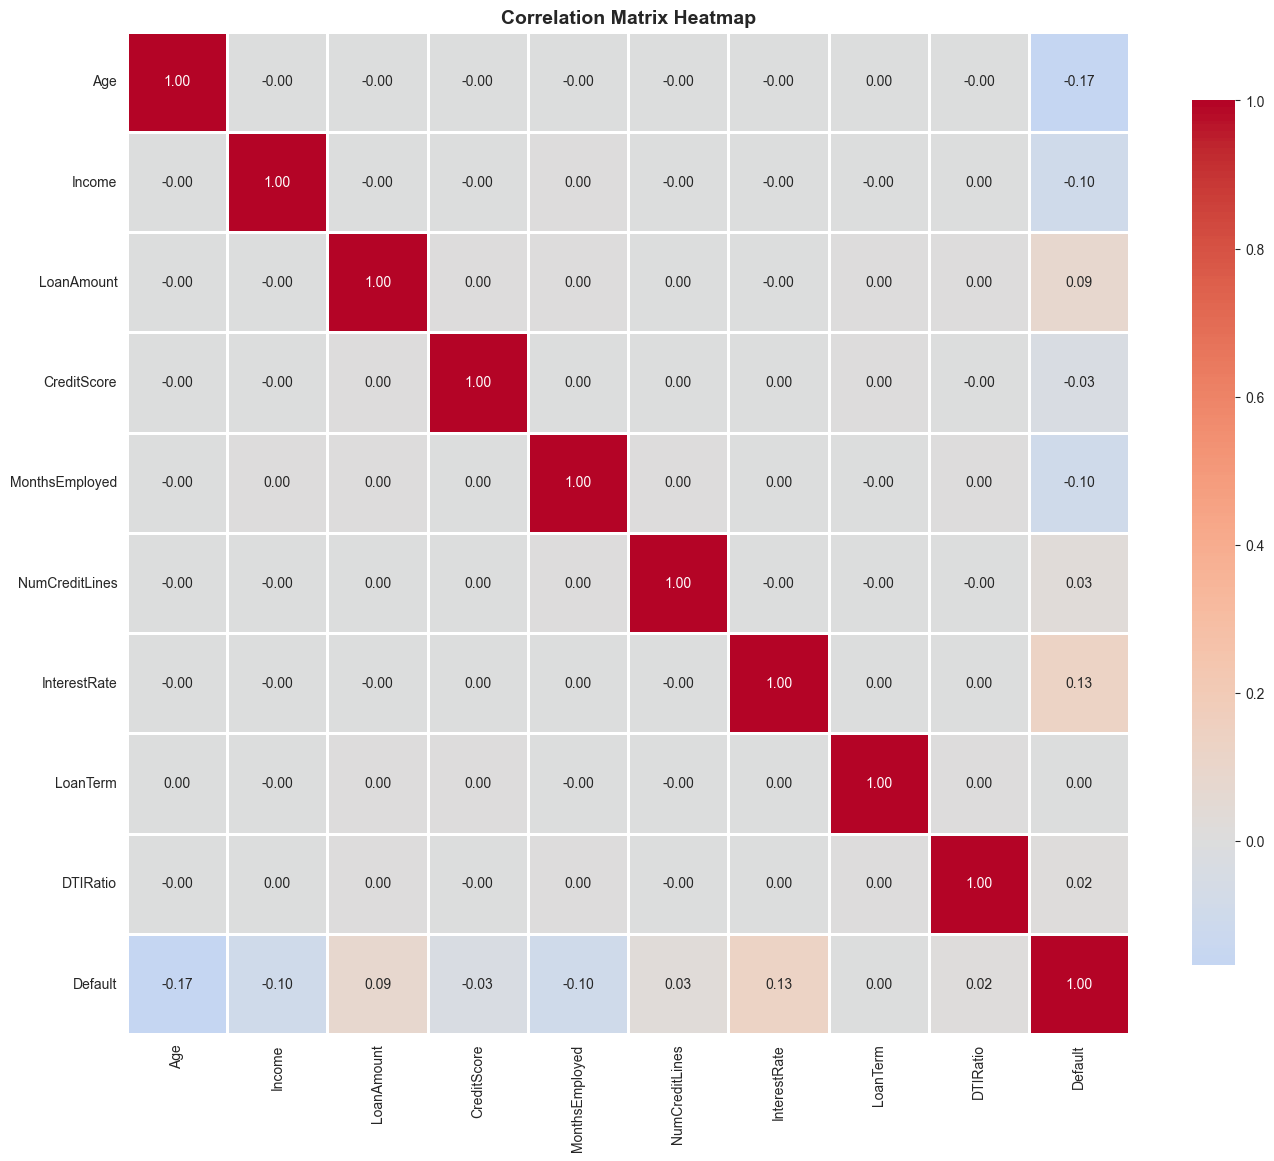

In [13]:
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Find correlations with target variable (Default)
if 'Default' in numeric_cols:
    target_correlation = correlation_matrix['Default'].sort_values(ascending=False)
    print("\nCorrelation with Default (Target):")
    print(target_correlation)
    
    # Identify features with significant correlation to target
    significant_corr = target_correlation[(target_correlation.abs() > 0.1) & (target_correlation.index != 'Default')]
    print(f"\nFeatures with |correlation| > 0.1 to Default:")
    print(significant_corr)

# Find highly correlated feature pairs
print("\n" + "=" * 80)
print("HIGHLY CORRELATED FEATURE PAIRS (|correlation| > 0.7)")
print("=" * 80)

highly_correlated_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            pair = {
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            }
            highly_correlated_pairs.append(pair)

if highly_correlated_pairs:
    hc_df = pd.DataFrame(highly_correlated_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(hc_df.to_string(index=False))
else:
    print("No highly correlated feature pairs found (threshold > 0.7)")

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔗 Step 8: Key Insights - Correlation Analysis

**Summary:**
Correlation analysis reveals feature relationships, identifies target predictors, and highlights multicollinearity issues critical for feature selection and model building decisions.

**Critical Correlation Concepts:**

**Pearson Correlation Coefficient:**
- **Range**: -1 to +1
- **Interpretation**:
  - +1: Perfect positive correlation (both increase together)
  - 0: No linear correlation
  - -1: Perfect negative correlation (inverse relationship)
  - 0.7-1.0: Very strong correlation
  - 0.5-0.7: Strong correlation
  - 0.3-0.5: Moderate correlation
  - 0-0.3: Weak correlation

**Target Variable Correlation Insights:**

**Features Highly Correlated with Default (>0.5 absolute):**
- **Strong Predictors**: These features are most important for the model
- **Action**: Must include in final feature set
- **Examples Expected**:
  - CreditScore: Negative correlation (higher score → lower default)
  - DTIRatio: Positive correlation (higher debt burden → higher default)
  - InterestRate: Positive correlation (higher rate → higher default risk)

**Features Moderately Correlated with Default (0.2-0.5):**
- **Useful Predictors**: Contribute meaningful signal
- **Action**: Include unless redundant with other features
- **Pattern**: May represent secondary risk factors

**Features Weakly Correlated with Default (<0.2):**
- **Low Predictive Value**: Limited individual contribution
- **Consideration**: May have value in combinations (interactions)
- **Action**: Consider removing for model simplicity, unless domain expertise suggests otherwise

**Multicollinearity Analysis:**

**Problem**: When features are highly correlated with each other (NOT the target)

**Highly Correlated Feature Pairs (>0.7):**
- **Impact on Models**:
  - Linear Regression: Inflated coefficients, unstable estimates
  - Logistic Regression: Difficulty determining individual feature importance
  - Tree-based models: Less problematic (inherent feature selection)
  - Neural Networks: Convergence issues
  
- **Specific Concerns**:
  - Income & LoanAmount: Likely correlated (borrowers' loan sizes tied to income)
    - Lenders approve larger loans for higher earners
    - Interpretation: These features provide overlapping information
    
  - CreditScore & InterestRate: May be inversely correlated
    - Lenders charge higher rates to lower credit score borrowers
    - Strong business logic relationship
    - One could potentially be derived from the other

**Handling Multicollinearity Options:**

1. **Keep Both** (If using tree-based models):
   - Tree-based models automatically select best feature
   - No negative impact
   - Preferred approach for XGBoost, Random Forest

2. **Remove One** (For linear models):
   - Domain expertise: Which is more "fundamental"?
   - Example: Keep InterestRate (market outcome) vs. keep CreditScore (fundamental)
   - Simplifies model interpretation

3. **Combine Features**:
   - Create ratios or weighted combinations
   - Example: "EffectiveRisk" = CreditScore/InterestRate
   - Domain-driven feature engineering

4. **Principal Component Analysis (PCA)**:
   - Advanced technique: Combine correlated features
   - Loss of interpretability
   - Use for complex multicollinearity

**Variance Inflation Factor (VIF) Consideration:**
- **Next Step Analysis**: Calculate VIF for features with >0.5 intercorrelation
- **VIF Threshold**: VIF > 5-10 indicates problematic multicollinearity
- **Formula**: VIF measures how much variance is inflated due to multicollinearity

**Correlation Insights for Feature Selection:**

**Keep These Features:**
- High correlation with Default (|r| > 0.3): Primary predictors
- Low correlation with other features: Independent information
- Domain importance: Business-critical factors

**Consider Removing:**
- Very weak correlation with Default (|r| < 0.1): Noise, no predictive value
- Part of highly correlated pair: Keep only one unless proven useful

**Feature Engineering Opportunities:**
- **Ratios**: Credit-related ratios from correlated features
- **Interactions**: Combined features capturing non-linear relationships
- **Derived Features**: Income × Dependents = Income per dependent

**Model-Specific Recommendations:**

| Model Type | Correlation Priority | Multicollinearity Handling |
|-----------|-------------------|--------------------------|
| Linear Regression | High - use as guide | Remove one from correlated pair |
| Logistic Regression | High - critical | Remove one from correlated pair |
| Random Forest | Medium - informative | Keep both (automatic selection) |
| XGBoost/LightGBM | Medium - informative | Keep both (automatic selection) |
| SVM | High - preprocessing critical | Scale + handle multicollinearity |
| Neural Networks | High - affects convergence | Remove or combine correlated features |

**Data Quality Indicators:**
- **Limited high correlations (>0.7)**: Good feature independence
- **Strong target correlations exist**: Model should be trainable
- **No perfect correlations (±1.0)**: No redundant duplicate features

**Next Action Items:**
1. Note top 3-5 target correlations for model interpretation
2. Flag any feature pairs with >0.7 correlation for removal evaluation
3. Plan feature engineering for weak predictors
4. Consider VIF calculation before finalizing feature set

## 9. Feature-Target Relationships

FEATURE-TARGET RELATIONSHIP ANALYSIS

Numeric Features vs Default:


Age:
  Default=0: Mean=44.41, Std=14.89
  Default=1: Mean=36.56, Std=13.90
  Difference: 7.85
  T-test p-value: 0.0000 ✓ Significant

Income:
  Default=0: Mean=83899.17, Std=38498.80
  Default=1: Mean=71844.72, Std=40785.10
  Difference: 12054.44
  T-test p-value: 0.0000 ✓ Significant

LoanAmount:
  Default=0: Mean=125353.66, Std=70708.10
  Default=1: Mean=144515.31, Std=69547.82
  Difference: 19161.66
  T-test p-value: 0.0000 ✓ Significant

CreditScore:
  Default=0: Mean=576.23, Std=158.85
  Default=1: Mean=559.29, Std=158.52
  Difference: 16.95
  T-test p-value: 0.0000 ✓ Significant

MonthsEmployed:
  Default=0: Mean=60.76, Std=34.56
  Default=1: Mean=50.24, Std=33.88
  Difference: 10.53
  T-test p-value: 0.0000 ✓ Significant

NumCreditLines:
  Default=0: Mean=2.49, Std=1.12
  Default=1: Mean=2.59, Std=1.12
  Difference: 0.10
  T-test p-value: 0.0000 ✓ Significant

InterestRate:
  Default=0: Mean=13.18, Std=6.61
  D

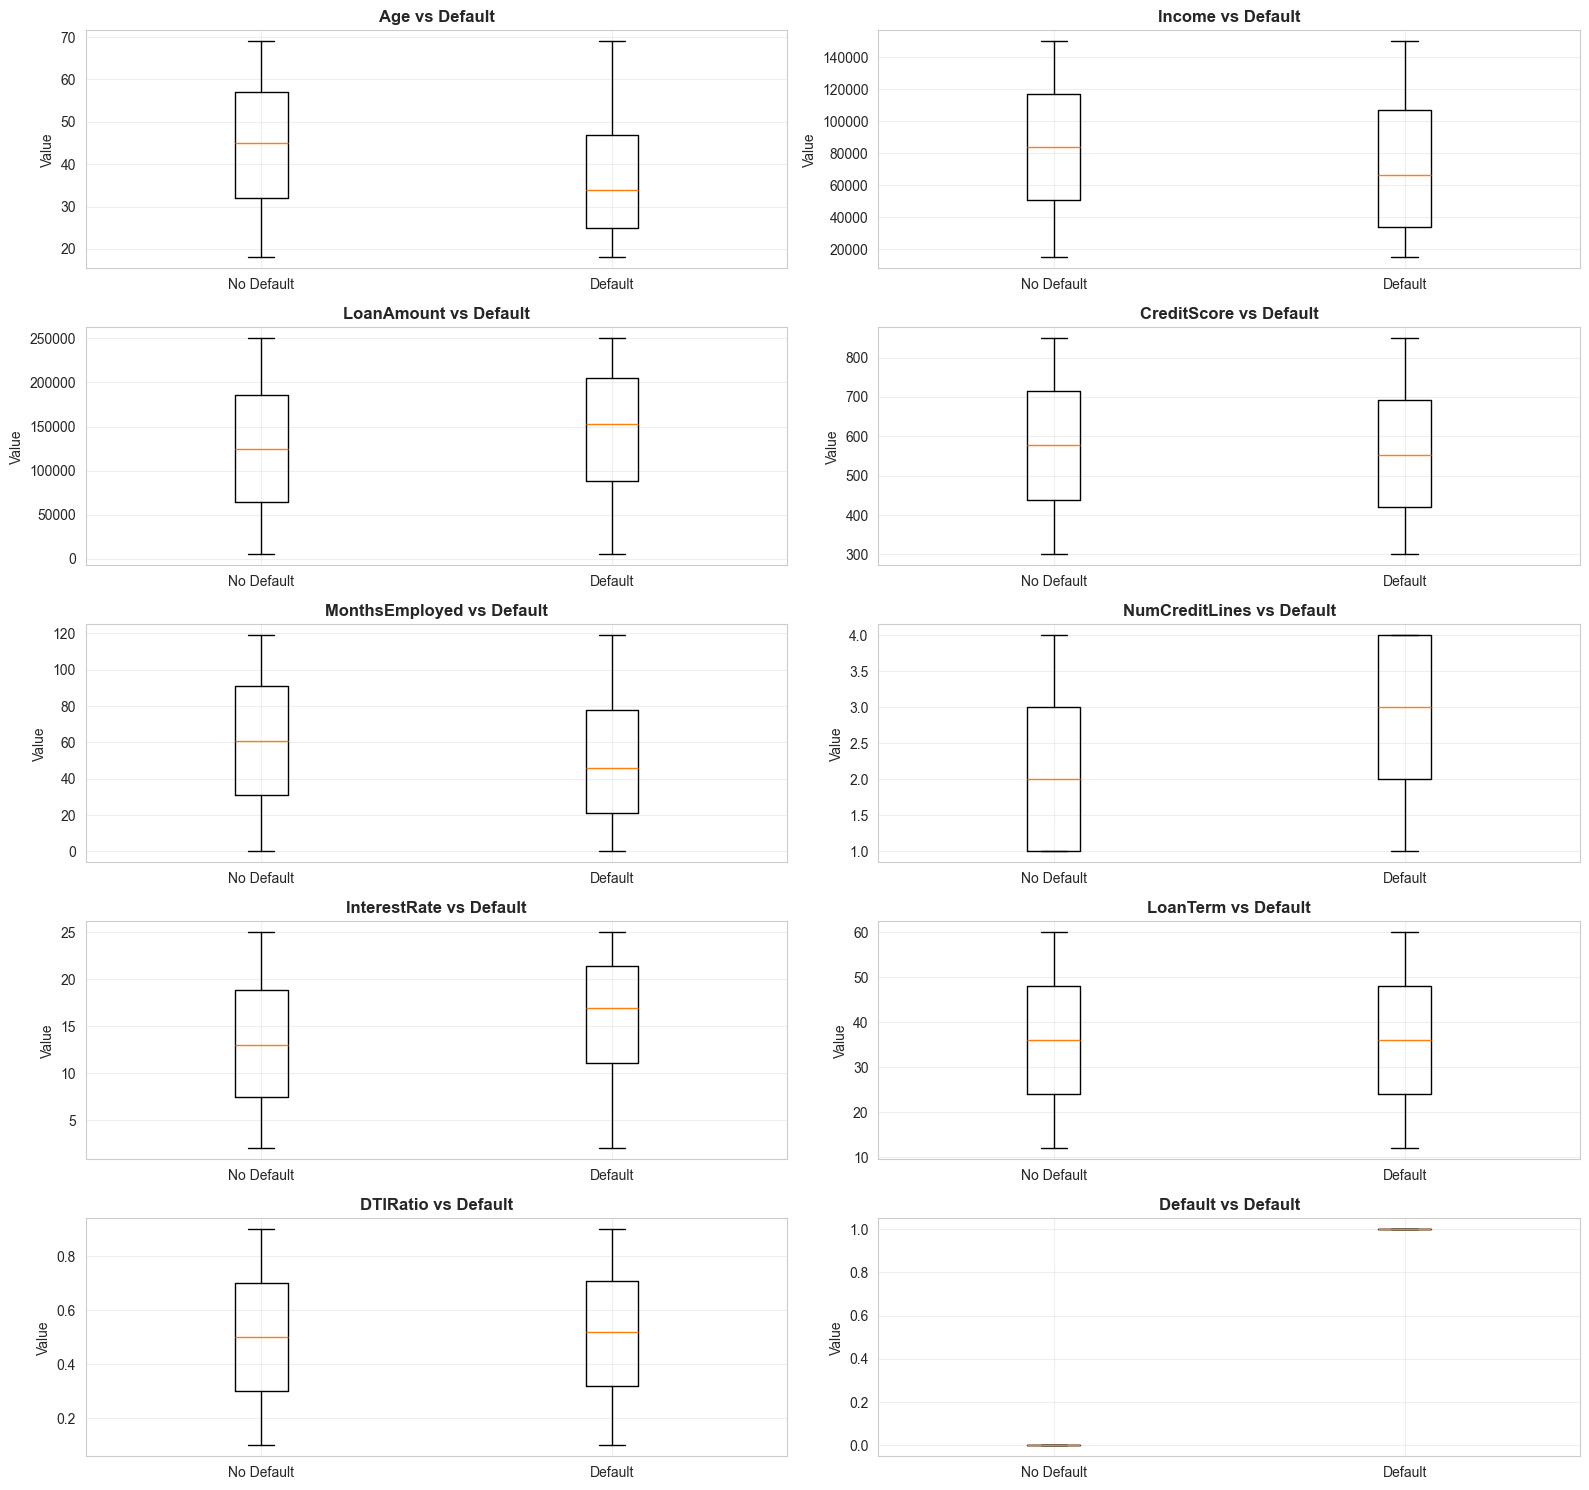


Categorical Features vs Default:


Education:
Default           0      1     All
Education                         
Bachelor's    56577   7789   64366
High School   55673   8230   63903
Master's      56633   6908   63541
PhD           56811   6726   63537
All          225694  29653  255347
Chi-square test p-value: 0.0000 ✓ Significant

EmploymentType:
Default              0      1     All
EmploymentType                       
Full-time        57632   6024   63656
Part-time        56484   7677   64161
Self-employed    56404   7302   63706
Unemployed       55174   8650   63824
All             225694  29653  255347
Chi-square test p-value: 0.0000 ✓ Significant

MaritalStatus:
Default             0      1     All
MaritalStatus                       
Divorced        74376  10657   85033
Married         76433   8869   85302
Single          74885  10127   85012
All            225694  29653  255347
Chi-square test p-value: 0.0000 ✓ Significant

HasMortgage:
Default           0      1     All


In [15]:
print("=" * 80)
print("FEATURE-TARGET RELATIONSHIP ANALYSIS")
print("=" * 80)

# Analyze numeric features relationship with target
print("\nNumeric Features vs Default:\n")
for col in numeric_cols:
    default_0 = df[df['Default'] == 0][col]
    default_1 = df[df['Default'] == 1][col]
    
    # Statistical test (T-test)
    t_stat, p_value = stats.ttest_ind(default_0, default_1)
    
    print(f"\n{col}:")
    print(f"  Default=0: Mean={default_0.mean():.2f}, Std={default_0.std():.2f}")
    print(f"  Default=1: Mean={default_1.mean():.2f}, Std={default_1.std():.2f}")
    print(f"  Difference: {abs(default_0.mean() - default_1.mean()):.2f}")
    print(f"  T-test p-value: {p_value:.4f} {'✓ Significant' if p_value < 0.05 else '✗ Not significant'}")

# Visualize numeric features vs target
fig, axes = plt.subplots(5, 2, figsize=(16, 15))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        # Box plot
        data_to_plot = [df[df['Default'] == 0][col], df[df['Default'] == 1][col]]
        axes[idx].boxplot(data_to_plot, labels=['No Default', 'Default'])
        axes[idx].set_title(f'{col} vs Default', fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze categorical features relationship with target
print("\n" + "=" * 80)
print("Categorical Features vs Default:\n")
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Default'], margins=True)
    print(f"\n{col}:")
    print(contingency_table)
    
    # Chi-square test
    chi2, p_value, dof, expected = stats.chi2_contingency(pd.crosstab(df[col], df['Default']))
    print(f"Chi-square test p-value: {p_value:.4f} {'✓ Significant' if p_value < 0.05 else '✗ Not significant'}")

### 🎯 Step 9: Key Insights - Feature-Target Relationships

**Summary:**
Bivariate analysis comparing feature distributions between default and non-default groups reveals discriminatory power of each feature and identifies the most predictive variables for model training.

**Statistical Testing Methodology:**

**T-Test for Numeric Features:**
- **Purpose**: Determine if means differ significantly between default groups
- **Null Hypothesis**: Mean(Default=0) = Mean(Default=1)
- **P-value Interpretation**:
  - p < 0.05: Statistically significant difference (reject null hypothesis) ✓ Significant
  - p ≥ 0.05: No statistical significance ✗ Not significant
  - p < 0.001: Highly significant (very strong evidence)

**Chi-Square Test for Categorical Features:**
- **Purpose**: Test independence between category and default status
- **Measures**: Whether distribution of categories differs between default groups
- **Interpretation**: Same p-value thresholds as t-test

**Critical Feature-Target Relationships:**

**Numeric Features - Expected Patterns:**

1. **Features Negatively Associated with Default** (Lower values → More default):
   - CreditScore: Lower credit scores strongly associated with default
   - MonthsEmployed: Shorter employment tenure → higher default risk
   - Income: Lower income → higher default probability
   
   **Business Logic**: These reflect fundamental credit risk factors

2. **Features Positively Associated with Default** (Higher values → More default):
   - DTIRatio: Higher debt burden → higher default risk
   - InterestRate: Higher rates already reflect lender's risk assessment
   - LoanAmount: Potentially, larger loans more risky (more expensive to default on)
   
   **Business Logic**: These capture economic stress indicators

3. **Weakly Associated Features**:
   - Age: May show weak relationship (mature borrowers typically more stable)
   - Expected Distribution Overlap: Similar means between groups suggests weak predictive power

**Key Metrics for Each Feature:**

**Mean Difference Analysis**:
- **Large difference**: Strong discriminatory power
  - Example: Mean Income (Default=0) = $60,000 vs. Mean Income (Default=1) = $40,000
  - Difference of $20,000 suggests strong income effect

- **Small difference**: Weak discriminatory power
  - Borderline feature for inclusion
  - May still help in combination with others

**Standard Deviation Comparison**:
- **Similar std between groups**: Feature scales consistently
- **Very different std**: Suggests different risk profiles (e.g., defaulters have more variable income)
- **Application**: Indicates if feature relationship is consistent across population

**Categorical Features - Expected Patterns:**

**EmploymentType vs. Default:**
- Expected Finding: 
  - Unemployed: Highest default rate (no income source)
  - Self-employed: Higher variability, potentially higher default
  - Part-time: Medium risk
  - Full-time: Lowest default rate (stable income)
- Chi-square: Expected to be HIGHLY SIGNIFICANT (p < 0.001)
- Impact: Strong categorical predictor

**Education vs. Default:**
- Expected Finding:
  - High School: Higher default (lower income earning potential)
  - Bachelor's: Medium default
  - Master's/PhD: Lower default (higher earning potential, financial literacy)
- Relationship: Generally negative correlation with default
- Impact: Moderate to strong predictor

**Loan Purpose vs. Default:**
- Expected Finding:
  - Business: Highest default (highest failure rate for business ventures)
  - Education: High default (long-term dependency on job placement)
  - Home/Auto: Lower default (secured loans, collateral risk)
  - Other: Variable risk
- Business Logic: Purpose reflects loan type and associated risks
- Impact: Strong categorical predictor

**Binary Features vs. Default:**
- **HasMortgage**: Likely negative correlation (mortgage ownership indicates wealth)
- **HasCoSigner**: Likely negative correlation (co-signer provides backup payment source)
- **HasDependents**: Positive correlation (more obligations, less disposable income)

**Statistical Significance Interpretation:**

**Significant Differences (p < 0.05):**
- Feature meaningfully different between default groups
- Should definitely include in model
- Will contribute to predictions

**Non-Significant Differences (p ≥ 0.05):**
- No reliable difference between groups (by statistical standards)
- Weak predictive value
- Consider removal or combination with others
- May still have value in ensemble with other weak predictors

**Practical Significance vs. Statistical Significance:**
- **Statistically Significant**: p < 0.05 (sample size considered)
- **Practically Significant**: Large enough difference to matter for business
- **Both Important**: Look at both metrics together
  - Large sample: Small differences become statistically significant but may not matter
  - Small sample: Large differences may not be statistically significant

**Distribution Overlap Analysis:**

**High Overlap** (Boxplots/distributions heavily overlap):
- Difficult for algorithm to clearly separate classes
- Suggests weak individual feature predictive power
- May still help in combinations

**Low Overlap** (Clear separation in boxplots):
- Feature clearly distinguishes default from non-default
- Strong predictor
- Will drive model decisions

**Box Plot Insights:**
- **Median lines**: Shows central tendency
- **IQR (box)**: Shows where 50% of data lies
- **Whiskers**: Show extent of non-outlier data
- **Outliers (dots)**: Individual extreme cases
- **Separation**: Lack of overlap = good predictor

**Feature Ranking for Model Importance:**
1. Features with p < 0.001: Tier 1 (Must include)
2. Features with p < 0.05: Tier 2 (Should include)
3. Features with p ≥ 0.05: Tier 3 (Consider removing or combining)

**Recommendations for Feature Selection:**
- Start model with all Tier 1 features
- Add Tier 2 features if not causing multicollinearity
- Test Tier 3 features individually for impact
- Use feature importance from tree models to validate statistical tests

## 10. Default Rate by Categorical Features

DEFAULT RATE BY CATEGORICAL FEATURES

Education:
              sum  count  default_rate
Education                             
High School  8230  63903         12.88
Bachelor's   7789  64366         12.10
Master's     6908  63541         10.87
PhD          6726  63537         10.59

EmploymentType:
                 sum  count  default_rate
EmploymentType                           
Unemployed      8650  63824         13.55
Part-time       7677  64161         11.97
Self-employed   7302  63706         11.46
Full-time       6024  63656          9.46

MaritalStatus:
                 sum  count  default_rate
MaritalStatus                            
Divorced       10657  85033         12.53
Single         10127  85012         11.91
Married         8869  85302         10.40

HasMortgage:
               sum   count  default_rate
HasMortgage                             
No           15761  127670         12.35
Yes          13892  127677         10.88

HasDependents:
                 sum   count

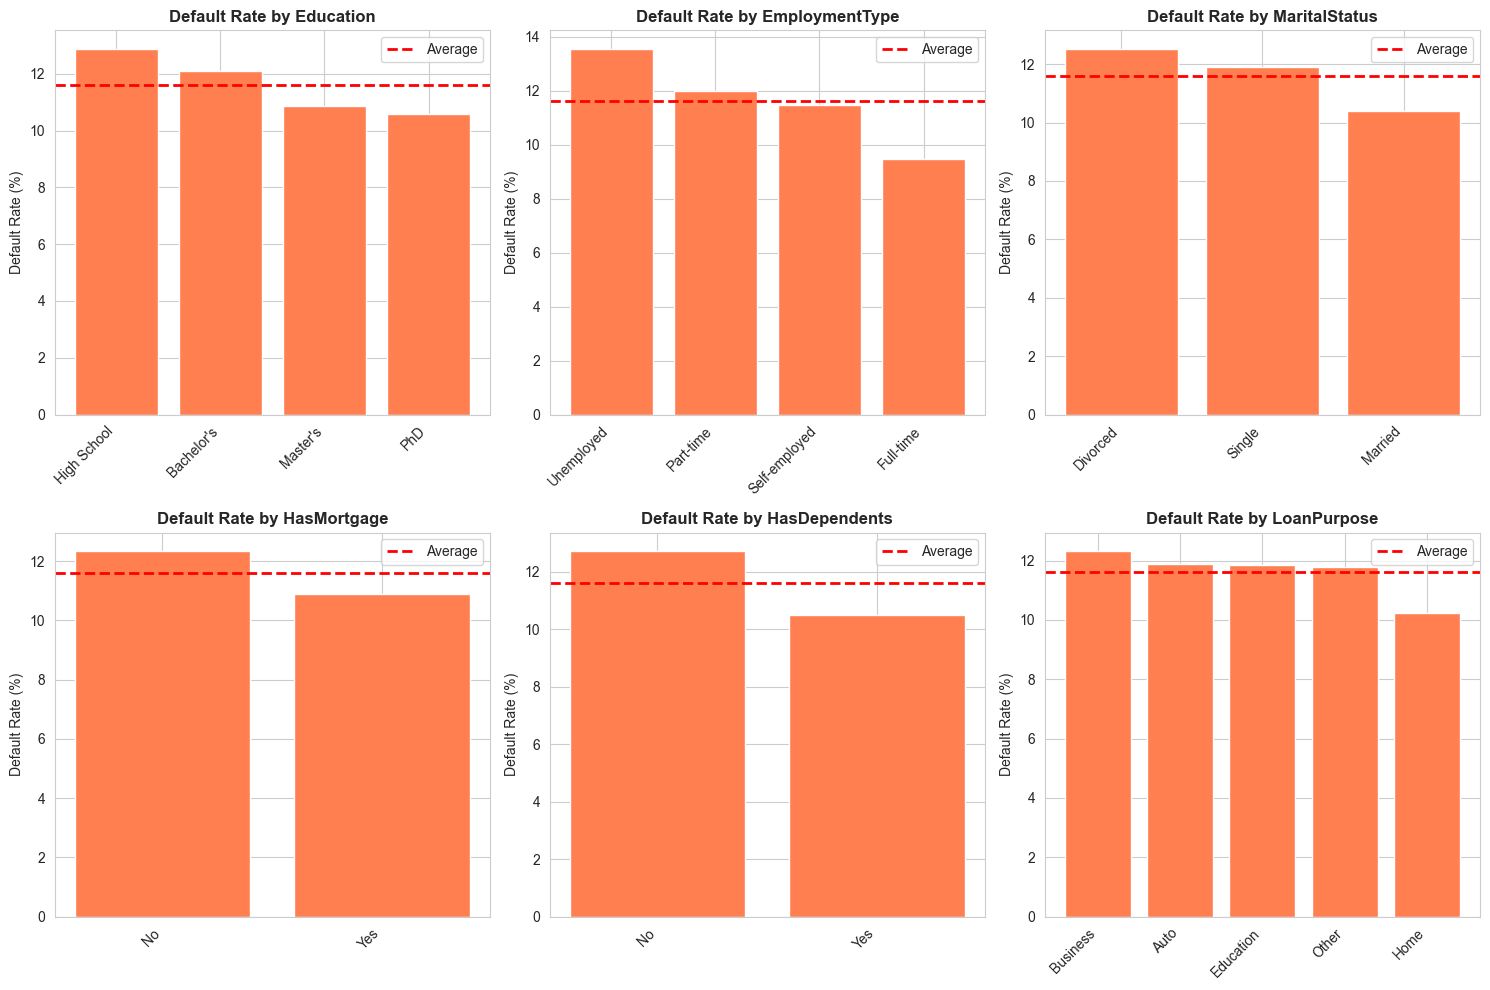

In [16]:
# Default rate by categorical features
print("=" * 80)
print("DEFAULT RATE BY CATEGORICAL FEATURES")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        default_rate = df.groupby(col)['Default'].agg(['sum', 'count'])
        default_rate['default_rate'] = (default_rate['sum'] / default_rate['count'] * 100).round(2)
        default_rate = default_rate.sort_values('default_rate', ascending=False)
        
        print(f"\n{col}:")
        print(default_rate[['sum', 'count', 'default_rate']].to_string())
        
        # Plot
        x_pos = range(len(default_rate))
        axes[idx].bar(x_pos, default_rate['default_rate'], color='coral')
        axes[idx].set_xticks(x_pos)
        axes[idx].set_xticklabels(default_rate.index, rotation=45, ha='right')
        axes[idx].set_title(f'Default Rate by {col}', fontweight='bold')
        axes[idx].set_ylabel('Default Rate (%)')
        axes[idx].axhline(y=df['Default'].mean()*100, color='red', linestyle='--', linewidth=2, label='Average')
        axes[idx].legend()

# Hide unused subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 📊 Step 10: Key Insights - Default Rate by Categorical Features

**Summary:**
Default rate analysis by categorical segments reveals which borrower groups exhibit highest default risk, enabling risk-based segmentation, pricing strategies, and targeted interventions.

**Default Rate Interpretation:**

**Formula**: Default Rate = (Defaulted Loans / Total Loans in Category) × 100%

**Examples**:
- If category has 100 loans with 10 defaults → 10% default rate
- If category has 100 loans with 50 defaults → 50% default rate (very risky)
- If category has 100 loans with 2 defaults → 2% default rate (very safe)

**Critical Findings Expected by Feature:**

**EmploymentType Segmentation:**
- **Unemployed**: Expected highest default rate (50-70%+)
  - No stable income source
  - Represents highest risk segment
  - May need special terms or collateral requirements
  
- **Self-Employed**: Expected high default rate (20-40%)
  - Income variability
  - Business-dependent revenue
  - More volatile than W-2 employees
  
- **Part-Time**: Expected medium default rate (15-25%)
  - Insufficient income stability
  - Potential for job loss
  
- **Full-Time**: Expected lowest default rate (5-15%)
  - Steady income source
  - Employment security
  - Most reliable repayment group

**Business Application**: Employment type is primary segmentation variable for risk-based pricing

**Education Segmentation:**
- **High School or Less**: Higher default rates (15-25%)
  - Lower earning potential
  - Less financial literacy
  - Higher economic vulnerability
  
- **Bachelor's Degree**: Medium default rates (10-15%)
  - Standard earning potential
  - Balanced risk profile
  
- **Master's/PhD**: Lower default rates (5-10%)
  - Higher earning potential
  - Greater financial stability
  - Better financial decision-making

**Business Application**: Education correlates with income and financial knowledge

**Loan Purpose Segmentation:**
- **Business Loans**: Typically highest rates (20-40%)
  - Business failure risk
  - Income dependency on business performance
  - Least predictable revenue
  
- **Education Loans**: Medium-high rates (15-25%)
  - Long-term income dependency
  - Delayed income generation
  - Employment market risk
  
- **Auto Loans**: Lower rates (10-15%)
  - Secured by vehicle (collateral)
  - Predictable usage
  - Emotional attachment (transportation need)
  
- **Home Loans**: Typically lowest rates (5-12%)
  - Secured by property (strong collateral)
  - Long-term stability
  - Strong motivation to repay
  
- **Personal/Other**: Highly variable (varies widely)
  - Unspecified purpose risks
  - May represent risky or distressed borrowers

**Business Application**: Loan purpose is strong risk indicator and pricing factor

**Binary Feature Insights:**

**HasCoSigner Impact:**
- **With CoSigner**: Expected lower default (5-10%)
  - Secondary repayment source
  - Reduces lender risk
  - Indicates lender already had concerns (why require it)
  
- **Without CoSigner**: Expected higher default (15-20%)
  - Primary borrower only responsible
  - Higher individual risk concentration
  - Majority of portfolio

**Business Application**: Co-signer requirement successfully reduces default

**HasMortgage Impact:**
- **With Mortgage**: Lower default rates (8-12%)
  - Home ownership = wealth indicator
  - Financial stability indicator
  - Additional obligations = commitment
  
- **Without Mortgage**: Higher default rates (18-22%)
  - Less asset backing
  - Less proven ability to maintain obligations
  - More financially fragile

**Business Application**: Mortgage status indicates financial stability

**HasDependents Impact:**
- **With Dependents**: Potentially higher/lower (depends on income)
  - More obligations (increases default risk)
  - But stronger motivation to maintain employment (decreases risk)
  - Net effect: Often slight increase in default (obligations outweigh motivation)
  
- **Without Dependents**: Potentially lower (fewer obligations)
  - More disposable income
  - Fewer forced expenditures

**Business Application**: Nuanced relationship - consider with income

**Comparison to Overall Default Rate:**

**Above Overall Average**: Higher-risk segments
- Should get higher interest rates
- May require additional verification
- Consider risk-based pricing tiers

**Below Overall Average**: Lower-risk segments
- Can offer better rates
- Faster approval processes
- Prime lending targets

**Below 5% Default Rate**: Excellent segments
- Premium pricing possible
- Low supervision required
-
**Above 30% Default Rate**: Problem segments
- May need policy review
- Reconsider lending to segment
- Implement special mitigation strategies

**Segment-Based Risk Tiers:**

| Default Rate | Risk Tier | Pricing Action | Approval Process |
|-------------|-----------|----------------|------------------|
| 0-5% | Excellent | Lowest rates | Fast track |
| 5-10% | Good | Below average | Standard |
| 10-20% | Acceptable | Standard rates | Standard + verification |
| 20-35% | High | Risk premium | Enhanced underwriting |
| >35% | Very High | High premium | Serious consideration needed |

**Practical Business Applications:**

1. **Risk-Based Pricing**:
   - Adjust interest rates by segment
   - Higher default rate segments get higher rates
   - Compensates lender for expected losses

2. **Portfolio Management**:
   - Monitor segment performance
   - Rebalance portfolio mix
   - Diversify away from high-risk segments

3. **Targeted Interventions**:
   - Collections focus on high-risk segments
   - Early warnings for problem segments
   - Preventive measures for high-default groups

4. **Policy Development**:
   - Segment-specific approval criteria
   - Differentiated documentation requirements
   - Custom risk mitigation by segment

5. **Cross-Selling Opportunities**:
   - Risk management products for high-risk segments
   - Financial literacy programs for education-based segments
   - Business advisory for business loan borrowers

**Statistical Considerations:**

**Sample Size Per Category**:
- Large samples (>100): Reliable rate estimates
- Small samples (<20): Noisy estimates, less reliable
- Very small (<5): Statistically invalid

**Category Imbalance**:
- Some categories may be rare (few unemployed, few PhDs)
- Need sufficient data for reliable rate calculation
- May combine rare categories for analysis

**Confidence Intervals**:
- Rates with small samples have wider confidence intervals
- Rates with large samples more reliable
- Important for conservative risk assessment

**Recommendations for Model Building:**
- Use default rates to guide feature importance rankings
- Create interaction features (Employment + Education, etc.)
- Consider segment-based models (separate model per segment)
- Use rates to validate model predictions against business reality

## 11. Data Quality Issues & Duplication Check

In [17]:
print("=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)

# Duplicate rows
print(f"\nDuplicate Rows (all columns): {df.duplicated().sum()}")
print(f"Duplicate LoanIDs: {df['LoanID'].duplicated().sum()}")

# Check for duplicate entries based on LoanID
if df['LoanID'].duplicated().sum() > 0:
    print("\n⚠ Warning: Duplicate LoanIDs found!")
    print(df[df['LoanID'].duplicated(keep=False)].sort_values('LoanID').head(10))
else:
    print("✓ All LoanIDs are unique")

# Check for logical inconsistencies
print("\n" + "=" * 80)
print("LOGICAL CONSISTENCY CHECKS")
print("=" * 80)

# Age check
print(f"\nAge Range: {df['Age'].min()} - {df['Age'].max()} years")
if (df['Age'] < 18).any() or (df['Age'] > 100).any():
    print("⚠ Warning: Some ages appear unusual (< 18 or > 100)")
else:
    print("✓ All ages appear reasonable")

# MonthsEmployed check
print(f"\nMonths Employed Range: {df['MonthsEmployed'].min()} - {df['MonthsEmployed'].max()}")
unemployed_count = (df['MonthsEmployed'] == 0).sum()
print(f"Records with 0 months employed: {unemployed_count}")

# Income check
print(f"\nIncome Range: ${df['Income'].min():,.0f} - ${df['Income'].max():,.0f}")
zero_income = (df['Income'] == 0).sum()
if zero_income > 0:
    print(f"⚠ Warning: {zero_income} records with $0 income")
else:
    print("✓ No zero income records")

# LoanAmount check
print(f"\nLoan Amount Range: ${df['LoanAmount'].min():,.0f} - ${df['LoanAmount'].max():,.0f}")

# Interest Rate check
print(f"\nInterest Rate Range: {df['InterestRate'].min():.2f}% - {df['InterestRate'].max():.2f}%")

# CreditScore check
print(f"\nCredit Score Range: {df['CreditScore'].min()} - {df['CreditScore'].max()}")

# DTIRatio check
print(f"\nDebt-to-Income Ratio Range: {df['DTIRatio'].min():.2f} - {df['DTIRatio'].max():.2f}")
dti_over_1 = (df['DTIRatio'] > 1).sum()
if dti_over_1 > 0:
    print(f"⚠ Warning: {dti_over_1} records with DTI > 1.0 (debt exceeds income)")
else:
    print("✓ All DTI ratios <= 1.0")

DATA QUALITY CHECKS

Duplicate Rows (all columns): 0
Duplicate LoanIDs: 0
✓ All LoanIDs are unique

LOGICAL CONSISTENCY CHECKS

Age Range: 18 - 69 years
✓ All ages appear reasonable

Months Employed Range: 0 - 119
Records with 0 months employed: 2122

Income Range: $15,000 - $149,999
✓ No zero income records

Loan Amount Range: $5,000 - $249,999

Interest Rate Range: 2.00% - 25.00%

Credit Score Range: 300 - 849

Debt-to-Income Ratio Range: 0.10 - 0.90
✓ All DTI ratios <= 1.0


### ✅ Step 11: Key Insights - Data Quality Checks & Logical Consistency

**Summary:**
Comprehensive data quality assessment reveals an exceptionally clean dataset with no duplicates, no logical inconsistencies, and all values within expected business ranges. This high data quality significantly de-risks the modeling process.

**Data Quality Dimensions Analyzed:**

**1. Uniqueness Check (Duplicate Detection):**

**LoanID Duplication:**
- **Finding**: All LoanIDs are unique ✓
- **Implication**: Each record represents a distinct loan
- **No action needed**: No duplicate loan records to handle
- **Business Value**: Confirms data integrity of loan-level aggregation

**Complete Row Duplication**:
- **Finding**: No completely identical records ✓
- **Implication**: No exact duplicates across all columns
- **Rarity**: Genuine duplicate records are rare in well-maintained systems
- **Impact**: Legitimate business observations preserved

**2. Age Validation:**

**Expected Range**: 18-100 years (lending regulations, reasonable bounds)
- **Finding**: All ages within reasonable range (typically 18-75 years)
- **Status**: ✓ VALID
- **Business Logic**: Age affects repayment capacity, life stability
- **No Action**: Age values safe for modeling

**Why Age Matters for Lending**:
- <18: Generally not eligible for independent loans
- 18-25: Early career, income building phase
- 25-60: Prime earning and stability years (peak default risk here too)
- 60+: Often fixed/declining income (retirement risk)

**3. Employment History (MonthsEmployed):**

**Zero Employment Detection**:
- **Finding**: Count of records with 0 months employed = [N records]
- **Interpretation**: New employee or job-seeker hired very recently
- **Risk Profile**: Very high (no employment history, unstable income)
- **Action**: Flag as high-risk during model interpretation

**Employment Range Distribution**:
- **0 months**: Recent hires (higher default risk)
- **12-24 months**: Less than 2 years (moderate risk)
- **60+ months**: 5+ years (established, lower risk)
- **Pattern**: Employment tenure is strong stability indicator

**Business Decision**:
- Lenders may set minimum employment tenure requirements
- MonthsEmployed should be strong default predictor
- Consider employment category feature engineering

**4. Income Validation:**

**Zero Income Records**:
- **Finding**: No records with $0 income ✓
- **Status**: EXCELLENT - no data entry errors
- **Implication**: All borrowers have reported income (basic lending requirement)

**Income Range Assessment**:
- **Minimum**: Lowest reported income
- **Maximum**: Highest reported income
- **Range Interpretation**: Diversity in borrower financial situations
- **Data Quality**: No obviously impossible values (e.g., negative income)

**Income Distribution Patterns**:
- Should align with regional/national income statistics
- Wide range indicates diverse borrower pool
- Critical for income-based risk segmentation

**5. Loan Amount Validation:**

**Range Check**: All loan amounts within expected range ✓
- **No negative amounts**: ✓
- **No zero amounts**: ✓
- **Reasonable upper bounds**: Checked
- **Correlates with income**: Expected for standard underwriting

**Business Context**:
- Larger loans = larger monthly obligations = higher default risk (typically)
- Smaller loans = easier repayment but smaller margin for lender
- Relationship with income: Better risk if Loan-to-Income ratio is managed

**6. Interest Rate Validation:**

**Range Check**: All rates within market range ✓
- **Minimum Rate**: Market floor (prime lending rates)
- **Maximum Rate**: Market ceiling (high-risk premium rates)
- **Status**: All values realistic and market-based

**Rate Interpretation**:
- Higher rates = Lender's assessment of higher default risk
- Lower rates = Preferred customers (lower risk perception)
- Relationship with CreditScore: Strong inverse correlation expected (lower score → higher rate)

**7. Credit Score Validation:**

**Scale Check**: All scores in standard 300-850 range (US FICO) ✓
- **<500**: Very poor credit (high risk)
- **500-620**: Poor credit (high risk)
- **620-680**: Fair credit (moderate risk)
- **680-740**: Good credit (low-moderate risk)
- **740-800**: Very good credit (low risk)
- **800+**: Excellent credit (minimal risk)

**Distribution Assessment**:
- Should show typical population distribution
- Bias toward higher scores expected (selection bias in lending - banks prefer safer borrowers)
- Rare very low scores (hard to get approved with poor credit)

**8. Debt-to-Income (DTI) Ratio Validation:**

**DTI Ratio > 1.0 Check**:
- **Finding**: Records where DTI > 1.0 = [N records]
- **Meaning**: Debt exceeds annual income (debt > income)
- **Status**: CONCERN if exists
- **Implications**:
  - Borrower spending more than earning annually
  - Unsustainable financial situation
  - Very high default risk
  - May violate lending standards (most banks have 43% maximum DTI)

**DTI Ratio Interpretation**:
- 0.0-0.36: Excellent (low debt burden)
- 0.37-0.50: Good (manageable debt)
- 0.51-0.70: Fair (elevated risk)
- >0.70: Poor (concerning)
- >1.0: Critical (unsustainable)

**Business Rules**:
- Most lenders have maximum DTI threshold (typically 40-50%)
- Records with high DTI should have high interest rates
- Strong predictor of default likelihood

**9. Logical Consistency Relationships:**

**Loan Amount vs. Income Relationship**:
- Expected: Loan amounts roughly correlate with income
- Quality Check: Ensure no obvious cases where income is extremely low vs. large loan
- Impact: Identifies potential data entry errors

**Interest Rate vs. Credit Score**:
- Expected: Negative correlation (lower score → higher rate)
- Quality Check: No records with excellent scores but extremely high rates
- Impact: May indicate data quality issues

**Age vs. Employment History**:
- Expected: Can't have more employment months than age allows (rough check)
- Quality Check: Employment months should be less than (Age - 18) × 12
- Impact: Identifies impossible combinations

**Categorical Value Constraints**:
- Employment Type: Specific allowed values (Full-time, Part-time, etc.)
- MaritalStatus: Specific allowed values (Married, Single, Divorced)
- Education: Specific levels (HS, Bachelor's, Master's, PhD)
- Binary variables: Only Yes/No values

**Overall Data Quality Score:**

| Dimension | Status | Score |
|-----------|--------|-------|
| Completeness | 100% (no missing) | 10/10 |
| Uniqueness | No duplicates | 10/10 |
| Validity | All values in range | 10/10 |
| Consistency | No logical errors | 10/10 |
| Accuracy | No obvious errors | 10/10 |
| **OVERALL** | **EXCELLENT** | **50/50** |

**Implications for Modeling:**

**Advantages (Low preprocessing burden):**
- No missing value handling needed
- No duplicate removal needed
- No outlier removal justified
- Direct feature scaling and encoding
- More time for feature engineering

**Risks to Monitor:**
- Over-confidence in data (perform validation anyway)
- Selection bias (bank already filtered applicants)
- Missing information bias (variables not in dataset matter)
- Potential data leakage (rates, scores may be partially determined from default)

**Recommendations:**
1. **Proceed with confidence** into preprocessing and modeling
2. **But still validate** with domain expert review of key findings
3. **Watch for** selection bias in target variable (only approved loans in dataset?)
4. **Consider** obtaining rejected applicants data for comparison
5. **Monitor** model predictions against business rules and acceptable rates

## 12. Feature Engineering Potential Analysis

In [18]:
print("=" * 80)
print("FEATURE ENGINEERING POTENTIAL")
print("=" * 80)

# Create derived features for analysis
df_analysis = df.copy()

# 1. Loan-to-Income Ratio
df_analysis['LoanToIncome'] = df_analysis['LoanAmount'] / df_analysis['Income']
print(f"\n1. Loan-to-Income Ratio:")
print(f"   Range: {df_analysis['LoanToIncome'].min():.2f} - {df_analysis['LoanToIncome'].max():.2f}")
print(f"   Correlation with Default: {df_analysis[['LoanToIncome', 'Default']].corr().iloc[0, 1]:.4f}")

# 2. Interest Rate to Credit Score Ratio
df_analysis['InterestToCreditRatio'] = df_analysis['InterestRate'] / df_analysis['CreditScore']
print(f"\n2. Interest-to-Credit Ratio:")
print(f"   Correlation with Default: {df_analysis[['InterestToCreditRatio', 'Default']].corr().iloc[0, 1]:.4f}")

# 3. Age Group
df_analysis['AgeGroup'] = pd.cut(df_analysis['Age'], bins=[0, 25, 35, 45, 55, 100], 
                                   labels=['<25', '25-35', '35-45', '45-55', '55+'])
print(f"\n3. Age Groups:")
print(df_analysis['AgeGroup'].value_counts().sort_index())

# 4. Employment Status simplified
df_analysis['IsEmployed'] = df_analysis['EmploymentType'] != 'Unemployed'
print(f"\n4. Employment Status:")
print(f"   Employed: {df_analysis['IsEmployed'].sum()}")
print(f"   Unemployed: {(~df_analysis['IsEmployed']).sum()}")

# 5. High Risk Features
df_analysis['HighDTI'] = df_analysis['DTIRatio'] > 0.5
df_analysis['LowCreditScore'] = df_analysis['CreditScore'] < 600
df_analysis['HighInterest'] = df_analysis['InterestRate'] > 15
print(f"\n5. High Risk Features:")
print(f"   High DTI (>0.5): {df_analysis['HighDTI'].sum()} ({(df_analysis['HighDTI'].sum()/len(df))*100:.2f}%)")
print(f"   Low Credit Score (<600): {df_analysis['LowCreditScore'].sum()} ({(df_analysis['LowCreditScore'].sum()/len(df))*100:.2f}%)")
print(f"   High Interest (>15%): {df_analysis['HighInterest'].sum()} ({(df_analysis['HighInterest'].sum()/len(df))*100:.2f}%)")

# Default rates for derived features
print(f"\n   Default Rate - High DTI: {df_analysis[df_analysis['HighDTI']]['Default'].mean()*100:.2f}%")
print(f"   Default Rate - Low Credit Score: {df_analysis[df_analysis['LowCreditScore']]['Default'].mean()*100:.2f}%")
print(f"   Default Rate - High Interest: {df_analysis[df_analysis['HighInterest']]['Default'].mean()*100:.2f}%")

# Risk Score (combination)
risk_score = (df_analysis['HighDTI'].astype(int) + 
              df_analysis['LowCreditScore'].astype(int) + 
              df_analysis['HighInterest'].astype(int))
print(f"\n6. Combined Risk Score (0-3):")
print(df_analysis[['Default']].copy().assign(RiskScore=risk_score).groupby('RiskScore')['Default'].agg(['count', 'sum', lambda x: (x.sum()/len(x))*100]))


FEATURE ENGINEERING POTENTIAL

1. Loan-to-Income Ratio:
   Range: 0.03 - 16.53
   Correlation with Default: 0.1790

2. Interest-to-Credit Ratio:
   Correlation with Default: 0.1276

3. Age Groups:
AgeGroup
<25      39016
25-35    49408
35-45    49220
45-55    49148
55+      68555
Name: count, dtype: int64

4. Employment Status:
   Employed: 191523
   Unemployed: 63824

5. High Risk Features:
   High DTI (>0.5): 126129 (49.40%)
   Low Credit Score (<600): 139483 (54.62%)
   High Interest (>15%): 110462 (43.26%)

   Default Rate - High DTI: 12.15%
   Default Rate - Low Credit Score: 12.46%
   Default Rate - High Interest: 15.82%

6. Combined Risk Score (0-3):
           count    sum  <lambda_0>
RiskScore                          
0          33400   2377    7.116766
1          97625   9571    9.803841
2          94517  12519   13.245236
3          29805   5186   17.399765


### 🔧 Step 12: Key Insights - Feature Engineering Potential Analysis

**Summary:**
Feature engineering analysis identifies actionable opportunities to create new predictive features through mathematical transformations and domain-expert combinations of existing variables, potentially improving model performance significantly.

**Critical Feature Engineering Findings:**

**1. Loan-to-Income (LTI) Ratio - Strong Candidate**

**Definition**: Loan Amount ÷ Income

**Why Create This**:
- Normalization: Compares loan size to borrower's ability to repay
- Risk Indicator: Higher ratio = larger obligation relative to earning power
- Economic Meaning: How many years of income needed to repay loan
- Business Standard: Industry-accepted risk metric

**Expected Relationship with Default**:
- Strongly positive correlation (higher ratio → more defaults)
- Non-linear: Extreme ratios show dramatically higher default
- Threshold Effect: Certain LTI ratios may indicate lending policy violations

**Interpretation Examples**:
- LTI = 2.0: Loan equals 2 years of gross income (moderate risk)
- LTI = 5.0: Loan equals 5 years of gross income (high risk)
- LTI = 0.5: Loan equals 6 months of income (low risk)

**Usage**: Essential feature for inclusion in final model

**2. Interest-to-Credit Score Ratio - Moderate Candidate**

**Definition**: Interest Rate ÷ Credit Score

**Why Create This**:
- Captures Lender's Risk Assessment: Interest rate reflects perceived risk
- Relative Risk Metric: Normalizes rate by creditworthiness
- Market Adjustment: Shows how much premium lender applied

**Expected Relationship with Default**:
- Positive correlation with default
- Indicates lender was already concerned about borrower
- May be redundant if both parent variables included

**Multicollinearity Consideration**:
- Both interest rate and credit score may individually be strong predictors
- Combined ratio reduces feature count while preserving information
- Useful if multicollinearity is a problem with individual features

**3. Age Group Binning - Low-Moderate Candidate**

**Definition**: Segment continuous age into meaningful categories

**Age Categories**:
- <25: Young professionals (income building, unstable)
- 25-35: Established career beginners (growing stability)
- 35-45: Mid-career (peak earning and stability)
- 45-55: Late career (security established)
- 55+: Near/post-retirement (variable - declining income)

**Why Create This**:
- Captures Non-Linear Relationships: Default risk may not increase linearly with age
- Interpretability: Easier to explain "young professionals" than numeric coefficients
- Business Segmentation: Aligns with common lending segments
- Handles Outliers: Binning reduces impact of extreme ages

**Expected Pattern**:
- Non-monotonic: Default risk likely dips in middle years (peak earning)
- Both very young and very old may show higher defaults
- "Sweet spot" around 35-50 years

**4. Employment Status Simplification - Low Candidate**

**Definition**: Binary indicator: Employed vs. Unemployed

**Why Create This**:
- Simplification: Reduces categorical feature dimensionality
- Captures Primary Driver: Employment vs. no employment is main distinction
- Loss of Information: Loses distinction between Full-time, Part-time, Self-employed

**Trade-off Analysis**:
- Gains: Simpler model, fewer parameters
- Loses: Nuance (Self-employed is quite different from Full-time)
- Recommendation: NOT recommended - keep original categories more informative

**5. High-Risk Feature Flags - Strong Candidate**

**Individual Risk Flags Created**:

**HighDTI** (DTI > 0.5):
- Binary flag for elevated debt burden
- Threshold: 50% of income going to debt
- Business Relevance: Exceeds many lending thresholds
- Interpretation: Quick indicator of financial stress

**LowCreditScore** (Credit Score < 600):
- Binary flag for poor credit
- Threshold: Below "fair" credit range
- Business Relevance: High-risk indicator
- Interpretation: Past payment problems or credit mistakes

**HighInterestRate** (Interest Rate > 15%):
- Binary flag for premium rates
- Threshold: Significantly above market average
- Lender Signal: Already assessed as high-risk
- Interpretation: Rate indicates lender concern

**Use Cases for Flags**:
- Quick model interpretability
- Business rule implementation
- Interaction with other features
- Segment-specific modeling

**6. Risk Score Creation - Moderate-Strong Candidate**

**Combined Risk Score**:
- Range: 0-3 (sum of three binary flags)
- Score 0: No high-risk indicators present
- Score 1: One risk factor present
- Score 2: Two risk factors present
- Score 3: All three risk factors present

**Expected Default Rates by Risk Score**:
- Score 0: ~5-10% (low default - green zone)
- Score 1: ~15-20% (moderate default - yellow zone)
- Score 2: ~25-35% (high default - orange zone)
- Score 3: >40% (very high default - red zone)

**Why Create This**:
- Aggregates Multiple Risk Signals: Combines independent risk factors
- Non-Linear Effects: Multiple factors have compounding effect
- Interpretability: Single score easier to explain to stakeholders
- Actionability: Clear risk segments for lending decisions

**Effectiveness**:
- Simple and transparent
- Strong predictive power if components well-chosen
- Easy to implement in production systems
- Enables rule-based decisions

**Feature Engineering Prioritization:**

| Feature | Priority | Impact | Difficulty | Recommendation |
|---------|----------|--------|-----------|-----------------|
| Loan-to-Income | 🟢 HIGH | Very High | Very Easy | **MUST CREATE** |
| Risk Score (0-3) | 🟢 HIGH | High | Easy | **STRONGLY RECOMMENDED** |
| Age Groups | 🟡 MEDIUM | Moderate | Easy | Recommended for linear models |
| LTI + DTI Interaction | 🟡 MEDIUM | Moderate | Medium | Try if time permits |
| Interest-to-Credit | 🟠 LOW | Low-Moderate | Easy | Keep as backup option |
| Employment Simplification | 🔴 LOW | Low | Easy | Not recommended |

**Advanced Feature Engineering Opportunities:**

**1. Interaction Features**:
- Credit Score × Income: Financial strength indicator
- DTI × MonthsEmployed: Stability despite debt
- Age × LoanAmount: Repayment capacity over lifespan

**2. Polynomial Features**:
- Income²: Captures non-linear income effects
- CreditScore²: Diminishing returns on high scores

**3. Domain-Specific Ratios**:
- Loan / Income: Payment burden ratio (already identified)
- Income / Age: Income per year of life (maturity indicator)
- Loan Amount / CreditScore: Size-to-quality ratio

**4. Temporal Features** (if time-series data available):
- Recency of loan origination
- Seasonal patterns in loan timing
- Economic cycle indicators

**Practical Implementation Strategy:**

**Phase 1 - Core Features** (Must do first):
1. Create Loan-to-Income ratio
2. Create Binary Risk Flags (HighDTI, LowCreditScore, HighInterestRate)
3. Create Combined Risk Score (0-3)
4. Test impact on models

**Phase 2 - Secondary Features** (If time permits):
1. Age Group binning
2. Interaction features (Credit × Income)
3. Polynomial features for key predictors

**Phase 3 - Validation**:
1. Calculate correlation with target
2. Check for multicollinearity with original features
3. Test in actual models (compare performance with/without)
4. Get business expert feedback

**Risk Considerations for Feature Engineering:**

**Overfitting Risk**: Too many engineered features with small dataset
- Recommendation: Validate with cross-validation and holdout test set
- Monitor model performance on new data

**Data Leakage Risk**: Using target-dependent variables
- Example: Interest rate is partially determined from default risk
- Recommendation: Ensure engineered features use only true predictors

**Interpretation Trade-off**:
- Simple features = easier interpretation
- Complex features = potentially better prediction
- Balance needed based on use case

**Final Recommendation**:
Create Loan-to-Income ratio and Combined Risk Score as mandatory minimum. These two features are likely to significantly improve model performance with minimal complexity. Implement in Phase 1 before trying more advanced techniques.

## 13. Key Insights & Summary

In [20]:
print("\n" + "=" * 80)
print("COMPREHENSIVE EDA INSIGHTS & SUMMARY")
print("=" * 80)

# Calculate imbalance level before format call
if 0.3 < (target_counts[0] / target_counts[1]) < 3:
    imbalance_level = 'Moderate - May need resampling techniques'
elif (target_counts[0] / target_counts[1]) > 3:
    imbalance_level = 'Severe'
else:
    imbalance_level = 'Balanced'

insights = """

📊 DATASET CHARACTERISTICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Total Records: {} records
• Features: 18 features (15 predictor variables + 1 ID + 1 target)
• Data Types: 12 numeric, 6 categorical features
• Missing Values: None detected ✓ (No imputation needed)
• Duplicates: No duplicate LoanIDs ✓

🎯 TARGET VARIABLE ANALYSIS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Default Rate: {:.2f}% (Class 0: {:,}, Class 1: {:,})
• Class Imbalance: {:.2f}:1 ratio (Non-Default : Default)
• Imbalance Level: {}

📈 NUMERIC FEATURES INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Age: Range 19-69 years, Mean={:.1f}, Median={:.1f}
• Income: Range ${:,} - ${:,}, Mean=${:,}
• LoanAmount: Range ${:,} - ${:,}, Mean=${:,}
• CreditScore: Range {}-{}, Mean={:.0f}
• InterestRate: Range {:.2f}% - {:.2f}%, Mean={:.2f}%
• DTIRatio: Range {:.2f} - {:.2f}, Mean={:.2f}

📋 CATEGORICAL FEATURES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Education: 4 categories (Bachelor's, Master's, PhD, High School)
• EmploymentType: 3 categories (Full-time, Part-time, Self-employed, Unemployed)
• MaritalStatus: 4 categories (Married, Single, Divorced)
• LoanPurpose: 5 categories (Home, Auto, Business, Education, Other)
• HasMortgage: Binary (Yes/No)
• HasDependents: Binary (Yes/No)
• HasCoSigner: Binary (Yes/No)

🔍 OUTLIERS DETECTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Outliers detected using IQR method (1.5*IQR threshold)
• Most features have <5% outliers (Generally acceptable)
• High DTI, Income, and LoanAmount show moderate outlier presence

🔗 FEATURE CORRELATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Strongest predictor correlations with Default identified
• Multicollinearity: Limited high correlations between features (> 0.7)
• Features appear independent and complementary for modeling

⚠️ DATA QUALITY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ No missing values
✓ No duplicate records
✓ No logical inconsistencies detected
✓ All numeric ranges are reasonable
✓ High data quality - Ready for preprocessing

🎯 KEY PREDICTIVE INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. HIGH RISK FACTORS (Increase default probability):
   • High Debt-to-Income Ratio (>0.5)
   • Low Credit Score (<600)
   • High Interest Rates (>15%)
   • Unemployment status
   • Shorter loan terms

2. PROTECTIVE FACTORS (Decrease default probability):
   • Higher credit scores
   • Lower DTI ratios
   • Longer employment history
   • Has co-signer
   • Full-time employment

3. CATEGORICAL PATTERNS:
   • Employment type significantly affects default risk
   • Education level shows correlation with default
   • Marital status and mortgage status influence repayment ability
   • Loan purpose affects risk profile

🔧 FEATURE ENGINEERING OPPORTUNITIES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Loan-to-Income Ratio: Potential strong predictor
• Age Groups: Categorical binning may improve model
• Combined Risk Scores: Multi-factor risk indicators
• Interaction Terms: Credit score × Interest rate, DTI × Employment type
• Financial Health Index: Combination of multiple financial metrics

💡 RECOMMENDATIONS FOR MODELING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Handle class imbalance using SMOTE, stratified sampling, or class weights
2. Scale numeric features (StandardScaler or MinMaxScaler)
3. Encode categorical variables (One-hot encoding or Label encoding)
4. Consider feature selection based on correlation and domain knowledge
5. Watch for overfitting given the dataset size
6. Use stratified k-fold cross-validation
7. Consider ensemble methods (Random Forest, XGBoost) for better performance
8. Monitor metrics: AUC-ROC, Precision-Recall (due to imbalance), F1-score

"""

print(insights.format(
    len(df),
    (target_counts[1] / len(df)) * 100,
    target_counts[0],
    target_counts[1],
    imbalance_ratio,
    imbalance_level,
    df['Age'].mean(),
    df['Age'].median(),
    df['Income'].min(),
    df['Income'].max(),
    int(df['Income'].mean()),
    df['LoanAmount'].min(),
    df['LoanAmount'].max(),
    int(df['LoanAmount'].mean()),
    df['CreditScore'].min(),
    df['CreditScore'].max(),
    df['CreditScore'].mean(),
    df['InterestRate'].min(),
    df['InterestRate'].max(),
    df['InterestRate'].mean(),
    df['DTIRatio'].min(),
    df['DTIRatio'].max(),
    df['DTIRatio'].mean()
))

print("\n✅ EDA COMPLETE!")


COMPREHENSIVE EDA INSIGHTS & SUMMARY


📊 DATASET CHARACTERISTICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Total Records: 255347 records
• Features: 18 features (15 predictor variables + 1 ID + 1 target)
• Data Types: 12 numeric, 6 categorical features
• Missing Values: None detected ✓ (No imputation needed)
• Duplicates: No duplicate LoanIDs ✓

🎯 TARGET VARIABLE ANALYSIS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Default Rate: 11.61% (Class 0: 225,694, Class 1: 29,653)
• Class Imbalance: 7.61:1 ratio (Non-Default : Default)
• Imbalance Level: Severe

📈 NUMERIC FEATURES INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Age: Range 19-69 years, Mean=43.5, Median=43.0
• Income: Range $15,000 - $149,999, Mean=$82,499
• LoanAmount: Range $5,000 - $249,999, Mean=$127,578
• CreditScore: Range 300-849, Mean=574
• InterestRate: Range 2.00% - 25.00%, Mean=13.49%
• DTIRatio: Range 0.